<a href="https://colab.research.google.com/github/pikey-msc/RiesgosFinancieros/blob/master/2027-1/SH_Integracion_python_pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📐 Riesgo de Mercado por Simulación Histórica — Portafolio Integrado

**Riesgos Financieros — 2026-1**

Este cuaderno mide el **riesgo de mercado** (VaR y CVaR/Expected Shortfall) de un portafolio con seis tipos de instrumentos: **acciones, divisas, Bondes D, swaps de tasa de interés, opciones de tasa de interés, forwards de tipo de cambio y forwards de índices** — usando **simulación histórica**.

### 🗺️ Ruta del cuaderno
1. **Funciones auxiliares** — interpolación de curvas (`talamb`), y cuantiles/CVaR histórico y **con alisado** (ponderación exponencial que da más peso a los escenarios recientes).
2. **Parámetros** — todo configurable con **campos de formulario** 📋: fecha de valuación, método de interpolación, nivel de confianza, factor de alisado, y las características de cada instrumento.
3. **Carga e integración de datos** — se descargan/leen todas las curvas y precios, y se alinean a las fechas que existen en **todas** las fuentes a la vez.
4. **Valuación** de cada instrumento a la fecha de valuación.
5. **Medición de riesgo** — para cada instrumento se revalúa bajo cada escenario histórico y se calcula VaR/CVaR (histórico y con alisado) a nivel **contrato** y a nivel **factor de riesgo**.
6. **Resumen integral** — se homologan e integran todos los resultados a **4 niveles**: contrato, instrumento, factor de riesgo (tasa de interés / acciones / divisas / volatilidad) y portafolio total.

> 🛠️ **Sobre esta revisión:** se completaron piezas que estaban a medias en la versión original (la función `talamb` se usaba en varias partes pero nunca se definía; la rama de tasa alambrada de Bondes D y Opciones estaba vacía; el forward de índices ignoraba los dividendos y tenía su descomposición de factores de riesgo rota), se corrigieron algunos bugs de cálculo, y se homologó el cálculo de VaR/CVaR (histórico y con alisado) en los 6 instrumentos con una sola función reutilizable, en vez de repetir la lógica –con pequeñas variaciones y errores– seis veces.

**Cómo usarlo:** ejecuta todo con *Entorno de ejecución → Ejecutar todas* la primera vez (tarda unos minutos por las descargas de Yahoo Finance); después cambia cualquier campo de formulario y vuelve a ejecutar desde ahí hacia abajo.


In [52]:
# @title 📦 Clonar el repositorio del curso (datos e insumos) { display-mode: "form" }
!rm -rf RiesgosFinancieros
!git clone "https://github.com/pikey-msc/RiesgosFinancieros/"


Cloning into 'RiesgosFinancieros'...
remote: Enumerating objects: 1374, done.
remote: Counting objects: 100% (167/167), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 1374 (delta 120), reused 68 (delta 68), pack-reused 1207 (from 2)
Receiving objects: 100% (1374/1374), 72.92 MiB | 23.25 MiB/s, done.
Resolving deltas: 100% (854/854), done.
Updating files: 100% (477/477), done.


# 🔧 Funciones auxiliares

Estas funciones se usan a lo largo de todo el cuaderno, para todos los instrumentos:

- **`talamb`** — interpolación de curvas por "tasa alambrada" (consistente con tasas forward), alternativa a la interpolación lineal.
- **`equantile` / `wquantile`** — cuantil de una muestra: `equantile` es el cuantil empírico normal (todas las observaciones pesan igual); `wquantile` es un **cuantil con alisado**, donde cada observación pesa según qué tan reciente es (peso $w_0\cdot(1-w_0)^{i-1}$ para la observación $i$-ésima más reciente). Esto es la base del **VaR con alisado**: en vez de que un choque de mercado de hace un año pese lo mismo que uno de ayer, los escenarios recientes dominan la estimación de riesgo.
- **`wcvar`** — el CVaR (pérdida promedio más allá del VaR) con la misma ponderación.

*(Nota: se agregó `talamb` porque el resto del cuaderno la invoca en varias partes, pero nunca estaba definida — solo funcionaba mientras el método de interpolación elegido fuera el lineal.)*


In [53]:
# @title Función talamb(): interpolación por "tasa alambrada" { display-mode: "both" }
import numpy as np

def talamb(nodos, curva, plazos):
    """
    Interpola tasas de interés de forma consistente con las tasas forward
    implícitas entre nodos (método "tasa alambrada", estándar del mercado
    mexicano para curvas gubernamentales). Fuera del rango de `nodos` se
    sostiene el valor del nodo más cercano (no se extrapola).
    """
    nodos = np.asarray(nodos, dtype=float).flatten()
    curva = np.asarray(curva, dtype=float).flatten()
    plazos = np.asarray(plazos, dtype=float).flatten()

    sorted_indices = np.argsort(nodos)
    nodos_sorted = nodos[sorted_indices]
    curva_sorted = curva[sorted_indices]

    indices = np.searchsorted(nodos_sorted, plazos) - 1
    indices[indices < 0] = 0
    indices[indices >= len(nodos_sorted) - 1] = len(nodos_sorted) - 2

    nodos_i = nodos_sorted[indices]
    nodos_i_plus_1 = nodos_sorted[indices + 1]
    TC_interp = curva_sorted[indices]
    TL_interp = curva_sorted[indices + 1]

    TF = np.where(plazos < nodos_sorted[0], curva_sorted[0],
             np.where(plazos > nodos_sorted[-1], curva_sorted[-1],
                      ((((1 + TL_interp * nodos_i_plus_1 / 360) / (1 + TC_interp * nodos_i / 360)) **
                        ((plazos - nodos_i) / (nodos_i_plus_1 - nodos_i)) *
                        (1 + TC_interp * nodos_i / 360)) - 1) * 360 / plazos))

    return TF


In [54]:
# @title Cuantiles y CVaR: histórico y con alisado { display-mode: "both" }
import numpy as np


def equantile(v, p=0.5):
    """Cuantil empírico más cercano de un vector (todas las observaciones pesan igual)."""
    v = np.asarray(v, dtype=float)
    if not (0 <= p <= 1):
        raise ValueError("El percentil debe estar en el rango [0, 1]")
    sorted_v = np.sort(v)
    n = len(sorted_v)
    plist = np.cumsum(np.ones(n) / n)
    return sorted_v[np.argmax(plist >= p)]


def pesos_alisado(n, w0):
    """
    Pesos decrecientes w0*(1-w0)**(i-1) para las observaciones 1..n, donde la
    observación 1 es la MÁS RECIENTE (mayor peso) y la observación n la más
    antigua (menor peso). Se usan para el VaR/CVaR "con alisado".
    """
    if n <= 0 or not (0 < w0 < 1):
        raise ValueError("n debe ser positivo y w0 debe estar en (0, 1)")
    return np.array([w0 * ((1 - w0) ** (i - 1)) for i in range(1, n + 1)])


def wquantile(v, w0, p=0.5):
    """
    Cuantil con alisado: igual que equantile, pero ponderando cada
    observación según su antigüedad (pesos_alisado). Se asume que `v` está
    ordenado de la observación más reciente (índice 0) a la más antigua.
    """
    v = np.asarray(v, dtype=float)
    n = len(v)
    w = pesos_alisado(n, w0)
    if not (0 <= p <= 1):
        raise ValueError("El percentil debe estar en el rango [0, 1]")

    sorted_indices = np.argsort(v)
    sorted_v = v[sorted_indices]
    sorted_w = w[sorted_indices]

    sum_w = np.cumsum(sorted_w)
    plist = sum_w / sum_w[-1]

    return sorted_v[np.argmax(plist >= p)]


def wcvar(v, w0, p=0.5):
    """CVaR con alisado: promedio ponderado de las pérdidas más allá del cuantil p con alisado."""
    v = np.asarray(v, dtype=float)
    n = len(v)
    w = pesos_alisado(n, w0)
    if not (0 <= p <= 1):
        raise ValueError("El nivel de confianza debe estar en el rango [0, 1]")

    sorted_indices = np.argsort(v)
    sorted_v = v[sorted_indices]
    sorted_w = w[sorted_indices]

    sum_w = np.cumsum(sorted_w)
    plist = sum_w / sum_w[-1]

    cola = sorted_v[plist < p]
    peso_cola = sorted_w[plist < p]
    if len(cola) == 0:
        return sorted_v[0]
    return np.sum(cola * peso_cola) / np.sum(peso_cola)


In [55]:
# @title Ejemplo rápido de uso { display-mode: "both" }
v = [4, 7, 1, 9, 3, 5, 8, 2, 6]
p = 0.6

print(f"Cuantil emp\u00edrico al {p*100:.0f}%: {equantile(v, p)}")
print(f"Cuantil con alisado al {p*100:.0f}% (w0=0.05): {wquantile(v, 0.05, p)}")
print(f"CVaR con alisado al {p*100:.0f}% (w0=0.05): {wcvar(v, 0.05, p):.4f}")


Cuantil empírico al 60%: 6.0
Cuantil con alisado al 60% (w0=0.05): 6.0
CVaR con alisado al 60% (w0=0.05): 3.0106


# 🎛️ Parámetros

Todo lo que se puede ajustar está aquí, agrupado por instrumento, como **celdas de formulario** 📋: cambia los valores en el panel de la derecha (o menú ⋮ de la celda → *Mostrar código* para ver/editar el Python) y vuelve a ejecutar el cuaderno desde ahí hacia abajo.

Se mantiene la convención del resto del curso: cada instrumento se define como un **vector de posiciones de ejemplo** (una mini cartera), con plazos, tasas/strikes, número de contratos y nominal.


In [93]:
# @title ⚙️ Parámetros generales { display-mode: "form" }
import numpy as np
from datetime import datetime, timedelta

fecha_valuacion = '2023-03-10'  # @param {type:"date"}
fval = datetime.strptime(fecha_valuacion.replace('-', ''), "%Y%m%d")  # Fecha de valuación

metodo_interpolacion = "Tasa alambrada"  # @param ["Interpolaci\u00F3n lineal", "Tasa alambrada"]
itpl = 0 if metodo_interpolacion == "Interpolaci\u00F3n lineal" else 1

nivel_confianza = 0.98  # @param {type:"number"}
alpha = nivel_confianza  # Nivel de confianza para VaR/CVaR

factor_alisado = 0.05  # @param {type:"number"}
w0 = factor_alisado  # Factor de decaimiento para el VaR/CVaR CON ALISADO (m\u00e1s peso a lo reciente)

dias_historia_mercado = 3660  # @param {type:"integer"}
nh = dias_historia_mercado  # d\u00edas de historia a descargar de Yahoo Finance

print(f"Fecha de valuaci\u00f3n: {fval:%d/%m/%Y}  |  M\u00e9todo de interpolaci\u00f3n: {metodo_interpolacion}")
print(f"Nivel de confianza: {alpha:.0%}  |  Factor de alisado (w0): {w0}  |  Historia: {nh} d\u00edas")


Fecha de valuación: 10/03/2023  |  Método de interpolación: Tasa alambrada
Nivel de confianza: 98%  |  Factor de alisado (w0): 0.05  |  Historia: 3660 días


In [57]:
# @title 🧾 Parámetros — Acciones y Divisas { display-mode: "form" }
# Los s\u00edmbolos DEBEN ir en orden alfab\u00e9tico dentro de cada lista (as\u00ed se
# alinean con las posiciones correspondientes)
Symbols = ["AMXB.MX", "GCARSOA1.MX", "WALMEX.MX"]  # @param {type:"raw"}
pos_eq = [-5000, 1000, 1200]  # @param {type:"raw"}
SymbolsFX = ["BTC-USD", "EURUSD=X", "USDMXN=X"]  # @param {type:"raw"}
pos_fx = [1.5, 700, 1500]  # @param {type:"raw"}


In [58]:
# @title 🧾 Parámetros — Bondes D { display-mode: "form" }
base = "RiesgosFinancieros/2024-1/Tarea/tasa_guber.txt" # @param {type:"string"}             # curva cup\u00f3n cero (tambi\u00e9n la usan CETES/Fwd \u00cdndices)
btasadescst = "RiesgosFinancieros/2024-1/Tarea/tasa_guber_st.txt" # @param {type:"string"}    # curva de sobretasa/spread
btasafondeo = "RiesgosFinancieros/2024-1/Tarea/tfondeo.txt"  # @param {type:"string"}        # serie hist\u00f3rica de tasa de fondeo

plazos_bdm = [358, 405, 550, 1200, 1800]  # @param {type:"raw"}
plazocupon_bdm = [28, 28, 28, 28, 28]  # @param {type:"raw"}
contratos_bdm = [220, -290, 290, -460, 100]  # @param {type:"raw"}
nominal_bdm = 100  # @param {type:"number"}

plazos_bdm = np.array(plazos_bdm)
plazocupon_bdm = np.array(plazocupon_bdm)
contratos_bdm = np.array(contratos_bdm)


In [59]:
# @title 🧾 Parámetros — Forwards de Tipo de Cambio { display-mode: "form" }
bext = "RiesgosFinancieros/2024-1/Tarea/tasa_libor.txt"   # @param {type:"string"} curva de tasas extranjera (USD)
bdom = "RiesgosFinancieros/2024-1/Tarea/tasa_fwd.txt"     # @param {type:"string"} curva de tasas dom\u00e9stica implícita en fwd

SymbolsFX_ftdc = ['USDMXN=X']  # @param {type:"raw"}
plazos_fwd = [360, 9, 35, 95, 183]  # @param {type:"raw"}
contratos_fwd = [500, -290, 290, -460, 440]  # @param {type:"raw"}
kst_fwd = [20.5, 19.4, 20.6, 20, 20.5]  # @param {type:"raw"}
nominal_fwd = 1  # @param {type:"number"}
yext = 1  # @param {type:"integer"}
trlib = 1  # @param {type:"integer"}
# yext: 1 si el spot USDMXN se descarga de Yahoo Finance en la fecha de valuaci\u00f3n; 0 si se usa tasa_spot.txt
# trlib: 1 si la curva libor viene compuesta a 182 d\u00edas; 0 si no

plazos_fwd = np.array(plazos_fwd)
contratos_fwd = np.array(contratos_fwd)
kst_fwd = np.array(kst_fwd)


In [60]:
# @title 🧾 Parámetros — Forward de Índices { display-mode: "form" }
# Se descuenta con la curva gubernamental (mismo archivo `base` de Bondes D)
SymbolsEQ_find = ["^MXX"]  # @param {type:"raw"}

plazos_fwd_ind = [360, 9, 3500]  # @param {type:"raw"}
contratos_fwd_ind = [5, -2, 5]  # @param {type:"raw"}
kst_fwd_ind = [52000, 49500, 60000]  # @param {type:"raw"}
nominal_fwd_ind = 1  # @param {type:"number"}

rendimiento_dividendos_ipc = 0.0  # @param {type:"number"}
# El archivo hist\u00f3rico de dividendos del IPC del repositorio solo llega
# hasta 2020, mucho antes de la ventana de fechas que usa este cuaderno
# (2022-2023): integrarlo como curva hist\u00f3rica dejar\u00eda vac\u00eda la
# intersecci\u00f3n de fechas de TODOS los factores de riesgo. En vez de eso se
# usa una tasa de dividendos FIJA y configurable aqu\u00ed. Al no variar en el
# tiempo, no aporta varianza al VaR (es una simplificaci\u00f3n expl\u00edcita, no
# un factor de riesgo simulado).

plazos_fwd_ind = np.array(plazos_fwd_ind)
contratos_fwd_ind = np.array(contratos_fwd_ind)
kst_fwd_ind = np.array(kst_fwd_ind)


In [61]:
# @title 🧾 Parámetros — Swaps { display-mode: "form" }
btasadesc_sw = "RiesgosFinancieros/2024-1/Tarea/tasa_TIIE_SW_OP.txt"   # @param {type:"string"} curva de descuento
btasacupvar_sw = "RiesgosFinancieros/2024-1/Tarea/tasa_DIRS_SW_OP.txt"  # @param {type:"string"} curva de cup\u00f3n variable

tasafija_sw = [0.079, 0.075]  # @param {type:"raw"}
plazos_sw = [588, 360]  # @param {type:"raw"}
plazocupon_sw = [28, 28]  # @param {type:"raw"}
contratos_sw = [-1600, 1000]  # @param {type:"raw"}
nominal_sw = [1, 1]  # @param {type:"raw"}
por_sw = [0, 0]  # @param {type:"raw"}

tasafija_sw = np.array(tasafija_sw)
plazos_sw = np.array(plazos_sw)
plazocupon_sw = np.array(plazocupon_sw)
contratos_sw = np.array(contratos_sw)
nominal_sw = np.array(nominal_sw)
por_sw = np.array(por_sw)


In [62]:
# @title 🧾 Parámetros — Opciones de Tasa de Interés { display-mode: "form" }
btasadesc_oir = "RiesgosFinancieros/2024-1/Tarea/tasa_TIIE_SW_OP.txt"    # @param {type:"string"} curva de descuento
btasaspot_oir = "RiesgosFinancieros/2024-1/Tarea/tasa_DIRS_SW_OP.txt"   # @param {type:"string"} curva de tasa spot (subyacente)
bvolspot_oir = "RiesgosFinancieros/2024-1/Tarea/tvoltiie_opc.txt"       # @param {type:"string"} curva de volatilidad

plazos_oir = [700, 1700, 400, 350, 200]  # @param {type:"raw"}
pr_oir = 28  # @param {type:"integer"}
dct_oir = 360  # @param {type:"integer"}
cp_oir = [1, 0, 0, 0, 0]  # @param {type:"raw"}
K_oir = [0.07, 0.085, 0.078, 0.085, 0.08]  # @param {type:"raw"}
contratos_oir = [2200, -2900, 2900, -460, 5000]  # @param {type:"raw"}
nominal_oir = 1  # @param {type:"number"}
cs_oir = 1  # @param {type:"integer"}
# cp_oir: 1 = call/cap, 0 = put/floor  |  cs_oir: 1 = tasa continua, 0 = tasa simple
# pr_oir: plazo de referencia del cup\u00f3n  |  dct_oir: base de d\u00edas

plazos_oir = np.array(plazos_oir)
cp_oir = np.array(cp_oir)
K_oir = np.array(K_oir)
contratos_oir = np.array(contratos_oir)


# 📥 Carga de datos

Se descargan/leen todas las fuentes de mercado que necesitan los seis instrumentos: precios de Yahoo Finance (acciones, divisas, USDMXN spot, IPC spot) y curvas de tasas/volatilidad del repositorio del curso. Cada celda de esta sección corresponde a un instrumento (o grupo de instrumentos que comparten insumos, como Bondes D y Forward de Índices, que ambos usan la curva gubernamental).



In [63]:
# @title 📥 Preparar yfinance { display-mode: "form" }
!pip install yfinance
import yfinance as yf
import pandas as pd


In [64]:
# @title 📥 Acciones y Divisas (Yahoo Finance) { display-mode: "form" }
start_date = datetime.now().date() - timedelta(days=nh)
symbol = Symbols + SymbolsFX

stock_prices = yf.download(symbol, start_date)
stock_prices_EQFX = stock_prices.Close.dropna()
# BTC-USD y EURUSD=X vienen en USD; los convertimos a MXN con el spot USDMXN
stock_prices_EQFX['EURUSD=X'] = stock_prices_EQFX['EURUSD=X'] * stock_prices_EQFX['USDMXN=X']
stock_prices_EQFX['BTC-USD'] = stock_prices_EQFX['BTC-USD'] * stock_prices_EQFX['USDMXN=X']
stock_prices_EQFX = stock_prices_EQFX[symbol]
stock_prices_EQFX = stock_prices_EQFX.reset_index()
stock_prices_EQFX['Date'] = stock_prices_EQFX['Date'].dt.tz_localize(None)
x0 = stock_prices_EQFX.tail(1)
x0

/tmp/ipykernel_728/1538956835.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_prices = yf.download(symbol, start_date)
[*********************100%***********************]  6 of 6 completed


Ticker,Date,AMXB.MX,GCARSOA1.MX,WALMEX.MX,BTC-USD,EURUSD=X,USDMXN=X
2513,2026-09-15,19.91,129.570007,45.560001,1.320806e+06,19.807328,17.16305


In [65]:
# @title 📥 Curvas — Bondes D (y curva gubernamental compartida) { display-mode: "form" }
# Curva gubernamental (cup\u00f3n cero): la usan Bondes D y, m\u00e1s adelante, Forward de \u00cdndices
data = pd.read_table(base, header=None)
n_gob = data.shape[0]
m_gov = data.shape[1]
x_orig_gov = pd.DataFrame(data.iloc[1:n_gob, 1:m_gov], dtype=float)
x_orig_gov['Date'] = pd.to_datetime(data.iloc[1:n_gob, 0], format="%Y%m%d")
nodos_gov = data.iloc[0, 1:m_gov]

# Curva de sobretasa/spread de Bondes D
data3 = pd.read_table(btasadescst, sep="\t", header=None)
n3 = data3.shape[0]
m3_bd = data3.shape[1]
X3a_orig_bd = data3.iloc[1:n3, 0:m3_bd]
X3_orig_bd = pd.DataFrame(data3.iloc[1:n3, 1:m3_bd], dtype=float)
X3_orig_bd['Date'] = pd.to_datetime(X3a_orig_bd[0], format='%Y%m%d')
nodos3_bd = data3.iloc[0, 1:m3_bd]

# Serie hist\u00f3rica de tasa de fondeo
data2 = pd.read_table(btasafondeo, sep="\t", header=None)
n2 = data2.shape[0]
X2_orig = data2.iloc[1:n2, 0:2]
X2_orig_bd = X2_orig.copy()
X2_orig_bd[0] = pd.to_datetime(X2_orig_bd[0], format='%Y%m%d')
X2_orig_bd[1] = X2_orig_bd[1].astype(float)

# Rellenamos d\u00edas sin dato (fines de semana/feriados) con la \u00faltima tasa vigente
tfh = pd.date_range(start=min(X2_orig_bd[0]), end=max(X2_orig_bd[0]), freq='D')
tfhd = pd.DataFrame({'fecha': tfh}).sort_values(by='fecha', ascending=True)
X2_orig_bd = X2_orig_bd.sort_values(by=0, ascending=True).rename(columns={0: 'fecha'})
X2_orig_bd = pd.merge_asof(tfhd, X2_orig_bd, on='fecha', direction='backward')
X2_orig_bd = pd.merge(tfhd, X2_orig_bd, on='fecha', how='outer')

# Tasa de fondeo vigente en la fecha de valuaci\u00f3n, y la serie de tasas
# realizadas durante el periodo de cup\u00f3n en curso (para el cup\u00f3n devengado)
tf_act = X2_orig_bd.loc[X2_orig_bd['fecha'] == fval, 1].values[0] / 100
tf_int = X2_orig_bd.loc[(X2_orig_bd['fecha'] <= fval) & (X2_orig_bd['fecha'] >= (fval - timedelta(int(plazocupon_bdm[0])))), 1] / 100
tf_int = tf_int[::-1]  # de m\u00e1s reciente a m\u00e1s antigua


In [66]:
# @title 📥 Curvas — Forwards de Tipo de Cambio { display-mode: "form" }
data1 = pd.read_table(bext, header=None)
data2 = pd.read_table(bdom, header=None)

n1 = data1.shape[0]
n2 = data2.shape[0]
m1_ftdc = data1.shape[1]
m2_ftdc = data2.shape[1]

nodos1_ftdc = data1.iloc[0, 1:m1_ftdc]
nodos2_ftdc = data2.iloc[0, 1:m2_ftdc]

x1_ftdc = pd.DataFrame(data1.iloc[1:n1, 1:m1_ftdc], dtype=float)
x1_ftdc['Date'] = pd.to_datetime(data1.iloc[1:n1, 0], format="%Y%m%d")
x2_ftdc = pd.DataFrame(data2.iloc[1:n2, 1:m2_ftdc], dtype=float)
x2_ftdc['Date'] = pd.to_datetime(data2.iloc[1:n2, 0], format="%Y%m%d")  # antes usaba n1 por error de dedo

if yext == 1:
    start_date = datetime.now().date() - timedelta(days=nh)
    X3_ftdc = yf.download(SymbolsFX_ftdc, start_date)
    X3_ftdc = X3_ftdc.Close.dropna()
    X3_ftdc = X3_ftdc.reset_index()
else:
    data3 = pd.read_table(bext, header=None)
    n3 = data3.shape[0]
    m3 = data3.shape[1]
    x3_ftdc = pd.DataFrame(data3.iloc[1:n3, 1:m3], dtype=float)
    x3_ftdc['Date'] = pd.to_datetime(data3.iloc[1:n3, 0], format="%Y%m%d")


/tmp/ipykernel_728/321286295.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  X3_ftdc = yf.download(SymbolsFX_ftdc, start_date)
[*********************100%***********************]  1 of 1 completed


In [67]:
# @title 📥 Curva — Forward de Índices (IPC spot) { display-mode: "form" }
# La curva de descuento (gubernamental) ya se cargó arriba como x_orig_gov / nodos_gov
X3_find = yf.download(SymbolsEQ_find, start_date)
X3_find = X3_find.Close.dropna()
X3_find = X3_find.reset_index()


/tmp/ipykernel_728/3340623157.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  X3_find = yf.download(SymbolsEQ_find, start_date)
[*********************100%***********************]  1 of 1 completed


In [68]:
# @title 📥 Curvas — Swaps { display-mode: "form" }
data1 = pd.read_table(btasadesc_sw, header=None)
n1 = data1.shape[0]
m1_orig_sw = data1.shape[1]
X1_orig_sw = pd.DataFrame(data1.iloc[1:n1, 1:m1_orig_sw], dtype=float)
X1_orig_sw['Date'] = pd.to_datetime(data1.iloc[1:n1, 0], format='%Y%m%d')
nodos1_sw = data1.iloc[0, 1:m1_orig_sw]

data2 = pd.read_table(btasacupvar_sw, header=None)
n2 = data2.shape[0]
m2_orig_sw = data2.shape[1]
X2_orig_sw = pd.DataFrame(data2.iloc[1:n2, 1:m2_orig_sw], dtype=float)
X2_orig_sw['Date'] = pd.to_datetime(data2.iloc[1:n2, 0], format='%Y%m%d')  # antes usaba n1 por error de dedo
nodos2_sw = data2.iloc[0, 1:m2_orig_sw]


In [69]:
# @title 📥 Curvas — Opciones de Tasa de Interés { display-mode: "form" }
data1 = pd.read_table(btasadesc_oir, header=None)
n = data1.shape[0]
m1_orig_oir = len(data1.columns)
x1_orig_oir = pd.DataFrame(data1.iloc[1:n, 1:m1_orig_oir], dtype=float)
x1_orig_oir['Date'] = pd.to_datetime(data1.iloc[1:n, 0], format='%Y%m%d')
nodos1_oir = data1.iloc[0, 1:m1_orig_oir]

data2 = pd.read_table(btasaspot_oir, header=None)
n = len(data2)
m2_orig_oir = len(data2.columns)
x2_orig_oir = pd.DataFrame(data2.iloc[1:n, 1:m2_orig_oir], dtype=float)
x2_orig_oir['Date'] = pd.to_datetime(data2.iloc[1:n, 0], format="%Y%m%d")
nodos2_oir = data2.iloc[0, 1:m2_orig_oir]

data3 = pd.read_table(bvolspot_oir, header=None)
n = len(data3)
m3_orig_oir = len(data3.columns)
x3_orig_oir = pd.DataFrame(data3.iloc[1:n, 1:m3_orig_oir], dtype=float)
x3_orig_oir['Date'] = pd.to_datetime(data3.iloc[1:n, 0], format="%Y%m%d")
nodos3_oir = data3.iloc[0, 1:m3_orig_oir]


# 🔗 Integración de Insumos

Cada fuente de mercado (acciones, divisas, curvas, volatilidades) tiene su propio historial de fechas. Antes de poder simular escenarios históricos consistentes, nos quedamos con la **intersección de fechas que existe en TODAS las fuentes a la vez**, y alineamos cada una a esa misma lista de fechas, ordenada de la más reciente a la más antigua.


In [70]:
# @title 🔗 Alineación por fecha de todas las fuentes { display-mode: "form" }
def filter_on_date(base_df, join_df, description):
    if not isinstance(base_df, pd.DataFrame):
        base_df = pd.DataFrame({'Date': base_df})
    if not isinstance(join_df, pd.DataFrame):
        join_df = pd.DataFrame({'Date': join_df})

    result = pd.merge(base_df, join_df, on='Date', how='inner')[['Date']].drop_duplicates()
    print(f"Fechas en com\u00fan tras sumar {description}: {len(result)}")
    return result

# Lista de fuentes a intersectar por fecha (adem\u00e1s de stock_prices_EQFX, la base)
dataframes_to_join = [
    (x_orig_gov, "curva gubernamental"),
    (X3_orig_bd, "spread Bondes D"),
    (X3_ftdc, "spot USDMXN (fwd TDC)"),
    (x1_ftdc, "curva libor"),
    (x2_ftdc, "curva fwd dom\u00e9stica"),
    (X3_find, "spot IPC"),
    (X1_orig_sw, "curva descuento swap"),
    (X2_orig_sw, "curva cup\u00f3n variable swap"),
    (x1_orig_oir, "curva descuento opciones"),
    (x2_orig_oir, "curva spot opciones"),
    (x3_orig_oir, "curva volatilidad opciones"),
]

current_df = stock_prices_EQFX
for join_df, description in dataframes_to_join:
    current_df = filter_on_date(current_df, join_df, description)

current_df = current_df.drop_duplicates().sort_values(by="Date", ascending=False)
n = len(current_df)
print(f"\nTotal de fechas alineadas en todas las fuentes: {n}")


def join_and_drop_date(base_df, join_df, divide_by_100=False):
    """Filtra `join_df` a las fechas de `base_df`, ordena descendente y quita la columna de fecha."""
    result = pd.merge(base_df, join_df, on='Date', how='inner').sort_values('Date', ascending=False)
    result = result.drop(columns=['Date'])
    return result / 100 if divide_by_100 else result


stock_prices_EQFX = join_and_drop_date(current_df, stock_prices_EQFX)
x_orig_gov = join_and_drop_date(current_df, x_orig_gov)
X3_orig_bd = join_and_drop_date(current_df, X3_orig_bd)
x1_ftdc = join_and_drop_date(current_df, x1_ftdc, True)
x2_ftdc = join_and_drop_date(current_df, x2_ftdc, True)
X3_ftdc = join_and_drop_date(current_df, X3_ftdc)
X3_find = join_and_drop_date(current_df, X3_find)
X1_orig_sw = join_and_drop_date(current_df, X1_orig_sw, True)
X2_orig_sw = join_and_drop_date(current_df, X2_orig_sw, True)
x1_orig_oir = join_and_drop_date(current_df, x1_orig_oir, True)
x2_orig_oir = join_and_drop_date(current_df, x2_orig_oir, True)
x3_orig_oir = join_and_drop_date(current_df, x3_orig_oir)


Fechas en común tras sumar curva gubernamental: 255
Fechas en común tras sumar spread Bondes D: 255
Fechas en común tras sumar spot USDMXN (fwd TDC): 255
Fechas en común tras sumar curva libor: 255
Fechas en común tras sumar curva fwd doméstica: 255
Fechas en común tras sumar spot IPC: 255
Fechas en común tras sumar curva descuento swap: 255
Fechas en común tras sumar curva cupón variable swap: 255
Fechas en común tras sumar curva descuento opciones: 255
Fechas en común tras sumar curva spot opciones: 255
Fechas en común tras sumar curva volatilidad opciones: 255

Total de fechas alineadas en todas las fuentes: 255


# 🧭 Pasos para medir el riesgo por Simulación Histórica

Para **cada** instrumento vamos a definir y calcular:

1. **Histórico de factores de riesgo** — las curvas/precios ya alineados por fecha.
2. **Vector de precios/tasas actual** — el valor de esos factores en la fecha de valuación (fila 0).
3. **Valoración al día de hoy** — el valor del instrumento con los factores actuales.

Con eso, más adelante (sección "Medición de Riesgo") se **revalúa** cada instrumento bajo cada escenario histórico para obtener su distribución de pérdidas y ganancias, y de ahí el VaR/CVaR.


## Acciones y Divisas

In [20]:
# @title 🧮 Valuación — Acciones y Divisas { display-mode: "both" }
m_fx = len(pos_fx)
m_acc = len(pos_eq)
M_acc_div = pos_eq + pos_fx          # posiciones: primero acciones, luego divisas
x0_acc_div = stock_prices_EQFX.iloc[0, :]   # precios/spot vigentes en la fecha de valuaci\u00f3n
V0_acc_div = x0_acc_div * M_acc_div

print("Precios/spot vigentes:")
print(x0_acc_div)
print("\nValuaci\u00f3n de la posici\u00f3n (MXN):")
V0_acc_div


Precios/spot vigentes:
AMXB.MX            14.034496
GCARSOA1.MX       122.497803
WALMEX.MX          60.488136
BTC-USD        472003.066272
EURUSD=X           18.525420
USDMXN=X           17.538940
Name: 0, dtype: float64

Valuación de la posición (MXN):


,0
AMXB.MX,-70172.481537
GCARSOA1.MX,122497.802734
WALMEX.MX,72585.763550
BTC-USD,708004.599409
EURUSD=X,12967.793781
USDMXN=X,26308.410645


## Bondes D

In [71]:
# @title 🧮 Valuación — Bondes D { display-mode: "both" }
m = len(plazos_bdm)
N_bd = (plazos_bdm // plazocupon_bdm) + 1  # n\u00famero de cupones a pagar

VTplazos_bdm = np.zeros(np.sum(N_bd))
contratos_bdmT = np.zeros(np.sum(N_bd))
plazocupon_bdmT = np.zeros(np.sum(N_bd))
tasafijaT_bd = np.zeros(np.sum(N_bd))
ulNomT_bd = np.zeros(np.sum(N_bd))
Xvp_bd = np.zeros((n, len(VTplazos_bdm)))
Xst_bd = np.zeros((n, len(VTplazos_bdm)))

plazini_bd = plazos_bdm - plazocupon_bdm * (N_bd - 1)
ddv = plazocupon_bdm - plazini_bd  # d\u00edas ya transcurridos del cup\u00f3n en curso
tfcupon = np.zeros(m)
tfcupondev = np.zeros(m)
tfcupgen = ((1 + tf_act / 360) ** (plazocupon_bdm[0]) - 1) * 360 / plazocupon_bdm[0]

for j in range(m):
    tfcupondev[j] = ((np.prod(1 + tf_int[0:ddv[j]] / 360) - 1) * 360) / ddv[j]
    tfcupon[j] = (((1 + tfcupondev[j] * ddv[j] / 360) * (1 + tf_act / 360) ** (plazocupon_bdm[0] - ddv[j]) - 1) * 360) / plazocupon_bdm[0]

for j in range(m):
    sum_N_bd = np.sum(N_bd[:j + 1])
    sum_N_bd_prev = np.sum(N_bd[:j]) if j > 0 else 0
    if j == 0:
        VTplazos_bdm[:sum_N_bd] = np.arange(plazini_bd[j], plazos_bdm[j] + 1, plazocupon_bdm[j])
        contratos_bdmT[:sum_N_bd] = contratos_bdm[j]
        plazocupon_bdmT[:sum_N_bd] = plazocupon_bdm[j]
        ulNomT_bd[sum_N_bd - 1] = contratos_bdm[j]
        tasafijaT_bd[0] = tfcupon[j]
        tasafijaT_bd[1:sum_N_bd] = tfcupgen
    else:
        VTplazos_bdm[sum_N_bd_prev:sum_N_bd] = np.arange(plazini_bd[j], plazos_bdm[j] + 1, plazocupon_bdm[j])
        contratos_bdmT[sum_N_bd_prev:sum_N_bd] = contratos_bdm[j]
        plazocupon_bdmT[sum_N_bd_prev:sum_N_bd] = plazocupon_bdm[j]
        tasafijaT_bd[sum_N_bd_prev] = tfcupon[j]
        tasafijaT_bd[sum_N_bd_prev + 1:sum_N_bd] = tfcupgen
        ulNomT_bd[sum_N_bd - 1] = contratos_bdm[j]

# Interpolamos la curva gubernamental y la de spread al plazo de cada flujo.
# (La rama de tasa alambrada estaba sin implementar en la versi\u00f3n original;
# aqu\u00ed se completa reutilizando talamb(), igual que en Bonos_python.ipynb.)
for i in range(n):
    nodos_arr = np.array(nodos_gov, dtype=float)
    nodos3_arr = np.array(nodos3_bd, dtype=float)
    curva_i = np.array(x_orig_gov.iloc[i, :], dtype=float)
    curva3_i = np.array(X3_orig_bd.iloc[i, :], dtype=float)
    if itpl == 0:
        Xvp_bd[i, :] = np.interp(VTplazos_bdm, nodos_arr, curva_i, left=curva_i[0], right=curva_i[-1])
        Xst_bd[i, :] = np.interp(VTplazos_bdm, nodos3_arr, curva3_i, left=curva3_i[0], right=curva3_i[-1])
    else:
        Xvp_bd[i, :] = talamb(nodos_arr, curva_i, VTplazos_bdm)
        Xst_bd[i, :] = talamb(nodos3_arr, curva3_i, VTplazos_bdm)

X2_pr = pd.merge(X2_orig_bd, current_df, left_on='fecha', right_on='Date', how='inner').sort_values('Date', ascending=False)
X_bd_tc = (np.ones((n, len(contratos_bdmT))).T * (np.array(X2_pr[1]) / 100)).T
X_bd_ext = np.hstack((X_bd_tc, Xvp_bd, Xst_bd))


def bondeD(contratosT, nominal, tasafijaT, plazocuponT, VTplazos, Xvp, Xst, N, ulNomT):
    """Valúa uno o varios Bondes D: cupón realizado/proyectado, descontado con curva + spread."""
    V0 = np.zeros(len(N))
    V0f = (((contratosT * tasafijaT * (plazocuponT / 360)) + ulNomT) / (1 + (Xvp + Xst) * VTplazos / 360)) * nominal
    for j in range(len(N)):
        if j == 0:
            V0[j] = np.sum(V0f[:N[j]])
        else:
            V0[j] = np.sum(V0f[np.sum(N[:j]):np.sum(N[:j + 1])])
    return V0


V0_bd = bondeD(contratos_bdmT, nominal_bdm, tf_act, plazocupon_bdmT, VTplazos_bdm, Xvp_bd[0, :], Xst_bd[0, :], N_bd, ulNomT_bd)
print(V0_bd)


[ 22161.16372445 -29321.94144348  29380.02638582 -47178.52826046
  10480.28632024]


## Forwards de Tipo de Cambio

In [73]:
# @title 🧮 Valuación — Forwards de Tipo de Cambio { display-mode: "both" }
m = len(plazos_fwd)
X1_fwtdc = np.zeros((n, m))
X2_fwtdc = np.zeros((n, m))


def approx(x, y, new_x):
    """Interpolaci\u00f3n lineal simple (equivalente al `approx()` de R)."""
    return np.interp(new_x, x, y)


for j in range(n):
    if itpl == 0:
        X1_fwtdc[j, :] = approx(nodos1_ftdc, x1_ftdc.iloc[j, :], plazos_fwd)
        X2_fwtdc[j, :] = approx(nodos2_ftdc, x2_ftdc.iloc[j, :], plazos_fwd)
    else:
        X1_fwtdc[j, :] = talamb(np.array(nodos1_ftdc, dtype=float), np.array(x1_ftdc.iloc[j, :], dtype=float), plazos_fwd.astype(float))
        X2_fwtdc[j, :] = talamb(np.array(nodos2_ftdc, dtype=float), np.array(x2_ftdc.iloc[j, :], dtype=float), plazos_fwd.astype(float))

    if trlib == 1:
        X1_fwtdc[j, :] = ((1 + X1_fwtdc[j, :]) ** (plazos_fwd / 180) - 1) * 360 / plazos_fwd


def futuroTC(t, tl, tn, s, k):
    """Valor de un forward de tipo de cambio (o de \u00edndice): carry entre curva
    extranjera/dividendos (tl) y curva dom\u00e9stica/descuento (tn), sobre el spot s,
    contra el precio pactado k."""
    f = s * ((1 + tn * t / 360) / (1 + tl * t / 360))
    return (f - k) / (1 + t * tn / 360)


X3_ftdc = np.array(X3_ftdc)
X_futtdc = np.hstack((X1_fwtdc, X2_fwtdc, X3_ftdc))

V0_fwtdc = futuroTC(plazos_fwd, X1_fwtdc[0, :], X2_fwtdc[0, :], X3_ftdc[0, :], kst_fwd) * contratos_fwd * nominal_fwd
print(V0_fwtdc)


[-1110.46395701   533.74314962  -862.98482896  1036.76663938
 -1121.7424601 ]


## Forward de Índices

In [74]:
# @title 🧮 Valuación — Forward de Índices { display-mode: "both" }
m_ind = len(plazos_fwd_ind)

# Tasa de dividendos: fija/configurable (ver nota en Par\u00e1metros — Forward de \u00cdndices)
X1_fwind = np.full((n, m_ind), rendimiento_dividendos_ipc)
X2_fwind = np.zeros((n, m_ind))

for j in range(n):
    if itpl == 0:
        X2_fwind[j, :] = approx(nodos_gov, x_orig_gov.iloc[j, :], plazos_fwd_ind)
    else:
        X2_fwind[j, :] = talamb(np.array(nodos_gov, dtype=float), np.array(x_orig_gov.iloc[j, :], dtype=float), plazos_fwd_ind.astype(float))

X3_find = np.array(X3_find)
X_futind = np.hstack((X1_fwind, X2_fwind, X3_find))

V0_fwind = futuroTC(plazos_fwd_ind, X1_fwind[0, :], X2_fwind[0, :], X3_find[0, :], kst_fwd_ind) * contratos_fwd_ind * nominal_fwd_ind
print(V0_fwind)


[ 13916.8821241   -2943.55397213 109410.78309909]


## Swaps

In [77]:
# @title 🧮 Valuación — Swaps { display-mode: "both" }
nodosvp = nodos1_sw
nodostc = nodos2_sw
curvavp = X1_orig_sw
curvatc = X2_orig_sw

m = len(plazos_sw)
N = (plazos_sw // plazocupon_sw) + 1  # n\u00famero de cupones a pagar

VTplazos_sw = np.zeros(np.sum(N))
VTplazos_swc = np.zeros(np.sum(N))
contratos_swT = np.zeros(np.sum(N))
por_swT = np.zeros(np.sum(N))
plazocupon_swT = np.zeros(np.sum(N))
tasafija_swT = np.zeros(np.sum(N))
nominal_swT = np.zeros(np.sum(N))
Xvp = np.zeros((n, len(VTplazos_sw)))
Xtc = np.zeros((n, len(VTplazos_sw)))
Xtcc = np.zeros((n, len(VTplazos_sw)))
XtfwdT = np.zeros((n, len(VTplazos_sw)))

plazini_sw = plazos_sw - plazocupon_sw * (N - 1)

for j in range(m):
    sum_N = np.sum(N[:j + 1])
    sum_N_prev = np.sum(N[:j]) if j > 0 else 0
    if j == 0:
        VTplazos_sw[:sum_N] = np.arange(plazini_sw[j], plazos_sw[j] + 1, plazocupon_sw[j])
        VTplazos_swc[:sum_N] = np.concatenate(([0], VTplazos_sw[0:(sum_N - 1)]))
        contratos_swT[:sum_N] = contratos_sw[j]
        plazocupon_swT[:sum_N] = plazocupon_sw[j]
        nominal_swT[:sum_N] = nominal_sw[j]
        por_swT[:sum_N] = por_sw[j]
        tasafija_swT[:sum_N] = tasafija_sw[j]
    else:
        VTplazos_sw[sum_N_prev:sum_N] = np.arange(plazini_sw[j], plazos_sw[j] + 1, plazocupon_sw[j])
        VTplazos_swc[sum_N_prev:sum_N] = np.concatenate(([0], VTplazos_sw[sum_N_prev:(sum_N - 1)]))
        contratos_swT[sum_N_prev:sum_N] = contratos_sw[j]
        plazocupon_swT[sum_N_prev:sum_N] = plazocupon_sw[j]
        nominal_swT[sum_N_prev:sum_N] = nominal_sw[j]
        por_swT[sum_N_prev:sum_N] = por_sw[j]
        tasafija_swT[sum_N_prev:sum_N] = tasafija_sw[j]

for i in range(n):
    if itpl == 0:
        Xvp[i, :] = approx(nodosvp, curvavp.iloc[i, :], VTplazos_sw)
        Xtc[i, :] = approx(nodostc, curvatc.iloc[i, :], VTplazos_sw)
        Xtcc[i, :] = approx(nodostc, curvatc.iloc[i, :], VTplazos_swc)
    else:
        Xvp[i, :] = talamb(np.array(nodosvp, dtype=float), np.array(curvavp.iloc[i, :], dtype=float), VTplazos_sw)
        Xtc[i, :] = talamb(np.array(nodostc, dtype=float), np.array(curvatc.iloc[i, :], dtype=float), VTplazos_sw)
        Xtcc[i, :] = talamb(np.array(nodostc, dtype=float), np.array(curvatc.iloc[i, :], dtype=float), VTplazos_swc)

    XtfwdT[i, :] = ((1 + Xtc[i, :] * VTplazos_sw / 360) / (1 + Xtcc[i, :] * VTplazos_swc / 360) - 1) * 360 / plazocupon_swT

    j = 0
    while j < len(VTplazos_sw):
        if VTplazos_sw[j] <= plazocupon_swT[j]:
            XtfwdT[i, j] = Xtc[i, j]
        else:
            j = np.sum(N[0:(j + 1)]) - 1
        j += 1

X_sw = np.hstack((XtfwdT, Xvp))


def swap(por_swT, contratos_swT, nominal_swT, XtfwdT, tasafija_swT, plazocupon_swT, VTplazos_sw, Xvp, N):
    """Valúa uno o varios swaps: diferencia entre tasa variable proyectada y tasa fija, descontada."""
    V0 = np.zeros(len(N))
    V0f = (contratos_swT * (XtfwdT - tasafija_swT) * (plazocupon_swT / 360)) / ((1 + Xvp * VTplazos_sw / 360) * nominal_swT * ((-1) ** por_swT))
    for j in range(len(N)):
        if j == 0:
            V0[j] = np.sum(V0f[0:N[j]])
        else:
            V0[j] = np.sum(V0f[np.sum(N[0:j]):np.sum(N[0:(j + 1)])])
    return V0


V0_sw = swap(por_swT, contratos_swT, nominal_swT, XtfwdT[0, :], tasafija_swT, plazocupon_swT, VTplazos_sw, Xvp[0, :], N)
print(V0_sw)


[4.68388794 4.10668865]


/tmp/ipykernel_728/2380408754.py:30: RuntimeWarning: divide by zero encountered in divide
  ((((1 + TL_interp * nodos_i_plus_1 / 360) / (1 + TC_interp * nodos_i / 360)) **


## Opciones de Tasa de Interés

In [78]:
# @title 🧮 Valuación — Opciones de Tasa de Interés { display-mode: "both" }
import scipy.stats as stats

m = len(plazos_oir)
x1 = np.zeros((n, m))    # curva de descuento
x2tc = np.zeros((n, m))  # curva spot al plazo del cup\u00f3n
x2tl = np.zeros((n, m))  # curva spot al plazo del cup\u00f3n + plazo de referencia
x2 = np.zeros((n, m))    # tasa forward del subyacente
x3 = np.zeros((n, m))    # volatilidad

for i in range(n):  # antes iba range(n-1): dejaba la \u00faltima fecha hist\u00f3rica en ceros
    if itpl == 0:
        x1[i, :] = np.interp(plazos_oir, nodos1_oir, x1_orig_oir.iloc[i, :])
        x2tc[i, :] = np.interp(plazos_oir, nodos2_oir, x2_orig_oir.iloc[i, :])
        x2tl[i, :] = np.interp(plazos_oir + pr_oir, nodos2_oir, x2_orig_oir.iloc[i, :])
        x3[i, :] = np.interp(plazos_oir, nodos3_oir, x3_orig_oir.iloc[i, :])
    else:
        x1[i, :] = talamb(np.array(nodos1_oir, dtype=float), np.array(x1_orig_oir.iloc[i, :], dtype=float), plazos_oir.astype(float))
        x2tc[i, :] = talamb(np.array(nodos2_oir, dtype=float), np.array(x2_orig_oir.iloc[i, :], dtype=float), plazos_oir.astype(float))
        x2tl[i, :] = talamb(np.array(nodos2_oir, dtype=float), np.array(x2_orig_oir.iloc[i, :], dtype=float), (plazos_oir + pr_oir).astype(float))
        x3[i, :] = talamb(np.array(nodos3_oir, dtype=float), np.array(x3_orig_oir.iloc[i, :], dtype=float), plazos_oir.astype(float))
    x2[i, :] = (((1 + x2tl[i, :] * ((plazos_oir + pr_oir) / 360)) / (1 + x2tc[i, :] * (plazos_oir / 360))) - 1) * 360 / pr_oir

x01 = x1[0, :]  # Tasas de descuento
x02 = x2[0, :]  # Tasas spot (forward del subyacente)
x03 = x3[0, :]  # Volatilidades

X_oir = np.column_stack((x1, x2, x3))


def opctint(d, S, K_oir, vol, t, cp_oir, cs_oir, pr_oir, dct_oir):
    """Black-76 para un cap/floor de tasa de inter\u00e9s (un solo cupón/caplet)."""
    d1 = ((np.log(S / K_oir) + (vol ** 2) * t / (365 * 2)) * (1 / (vol * np.sqrt(t / 365)))) if cs_oir == 1 else ((np.log(S / K_oir) + (vol ** 2) * t / (360 * 2)) * (1 / (vol * np.sqrt(t / 360))))
    d2 = ((np.log(S / K_oir) - (vol ** 2) * t / (365 * 2)) * (1 / (vol * np.sqrt(t / 365)))) if cs_oir == 1 else ((np.log(S / K_oir) - (vol ** 2) * t / (360 * 2)) * (1 / (vol * np.sqrt(t / 360))))
    vp = (np.log(1 + d * t / 360) * 365 / t) if cs_oir == 1 else d
    if cs_oir == 1:
        f = ((S * stats.norm.cdf(d1 * (-1) ** cp_oir) - K_oir * stats.norm.cdf(d2 * (-1) ** cp_oir)) * (np.exp(-vp * t / 365)) * (-1) ** cp_oir) * (pr_oir / dct_oir) / (1 + S * pr_oir / dct_oir)
    else:
        f = ((S * stats.norm.cdf(d1 * (-1) ** cp_oir) - K_oir * stats.norm.cdf(d2 * (-1) ** cp_oir)) * (1 / (1 + vp * t / 360)) * (-1) ** cp_oir) * (pr_oir / dct_oir) / (1 + S * pr_oir / dct_oir)
    return f


V0_oir = opctint(x01, x02, K_oir, x03, plazos_oir, cp_oir, cs_oir, pr_oir, dct_oir) * contratos_oir * nominal_oir
print(V0_oir)


[ 1.43098147 -1.05639635  0.82795277 -0.079546    2.23075185]


# 🧩 Integración de factores y cálculo de variaciones históricas

Juntamos el valor de hoy y el histórico alineado de **todos** los factores de riesgo de los seis instrumentos en una sola matriz, y calculamos las **variaciones logarítmicas diarias** ($\Delta X = \ln(X_t/X_{t-1})$) que usaremos como escenarios de simulación histórica.


In [79]:
# @title 🧩 Matriz de factores de riesgo y variaciones históricas { display-mode: "both" }
n_if = np.zeros(6)  # vector (no matriz de 1 columna): as\u00ed cada n_if[k] ya es un escalar
n_if[0] = stock_prices_EQFX.shape[1]  # acciones y divisas
n_if[1] = X_bd_ext.shape[1]           # bonde D
n_if[2] = X_sw.shape[1]               # swaps
n_if[3] = X_oir.shape[1]              # opciones tasa de inter\u00e9s
n_if[4] = X_futtdc.shape[1]           # forwards de tipo de cambio
n_if[5] = X_futind.shape[1]           # forwards de \u00edndices
n_if = n_if.astype(int)

# Valor del portafolio hoy
V0_port = np.hstack((V0_acc_div, V0_bd, V0_sw, V0_oir, V0_fwtdc, V0_fwind))
V0T_port = np.sum(V0_port)

# Integraci\u00f3n de todos los factores de riesgo en una sola matriz
X_port = np.hstack((stock_prices_EQFX, X_bd_ext, X_sw, X_oir, X_futtdc, X_futind))

# Variaciones \u0394X hist\u00f3ricas (retornos log diarios)
DeltaX_port = np.log(X_port[0:(n - 1), :] / X_port[1:n, :])
DeltaX_port[np.isnan(DeltaX_port)] = 0
DeltaX_port[np.isinf(DeltaX_port)] = 0

Ns = DeltaX_port.shape[0]  # n\u00famero de escenarios hist\u00f3ricos

print(f"Factores de riesgo por instrumento (columnas): {n_if.flatten()}")
print(f"Total factores de riesgo: {DeltaX_port.shape[1]}  |  Escenarios hist\u00f3ricos (Ns): {Ns}")
print(f"Valor del portafolio hoy: {V0T_port:,.2f}")


Factores de riesgo por instrumento (columnas): [  6 468  70  15  11   7]
Total factores de riesgo: 577  |  Escenarios históricos (Ns): 254
Valor del portafolio hoy: 976,584.47


/tmp/ipykernel_728/2140134301.py:19: RuntimeWarning: invalid value encountered in divide
  DeltaX_port = np.log(X_port[0:(n - 1), :] / X_port[1:n, :])


# 📊 Medición de Riesgo

Para cada instrumento, revaluamos la posición bajo **cada uno de los `Ns` escenarios históricos** (aplicando la variación `ΔX` observada ese día a los factores de riesgo de hoy), obtenemos la pérdida/ganancia resultante, y calculamos VaR y CVaR — histórico **y con alisado** — a nivel **contrato** (cada posición) y a nivel **factor de riesgo** (qué parte de la revaluación viene de cada curva/precio subyacente, dejando los demás factores fijos).

Para no repetir (y volver a equivocar) la misma lógica de VaR/CVaR seis veces, se usa una sola función homologada, `resumen_riesgo()`, que se aplica igual a los seis instrumentos.


In [82]:
# @title 🧮 Función homologada: VaR/CVaR histórico y con alisado { display-mode: "both" }
def resumen_riesgo(PG, alpha, w0):
    """
    Calcula VaR y CVaR --histórico y con alisado-- a partir de una matriz de
    pérdidas y ganancias `PG` (Ns escenarios x k posiciones/factores).

    Se usa exactamente igual para los 6 instrumentos, a nivel contrato
    (una columna por posición) y a nivel factor de riesgo (una columna por
    factor, ya aislado): así los resultados quedan homologados entre
    instrumentos en vez de recalcular la misma fórmula seis veces con
    variaciones (y bugs) distintos.

    Regresa un dict con, por columna, VaR/CVaR histórico y con alisado, y
    los mismos cuatro valores para el TOTAL (suma de todas las columnas).
    """
    PG = np.asarray(PG, dtype=float)
    if PG.ndim == 1:
        PG = PG.reshape(-1, 1)
    k = PG.shape[1]
    p = 1 - alpha

    def cvar_de(col, var_j):
        # Si ning\u00fan escenario queda estrictamente por debajo del VaR (colas con
        # empates, muestras chicas), se incluyen los empates para no dividir 0/0.
        cola = col[col < var_j]
        if cola.size == 0:
            cola = col[col <= var_j]
        return cola.mean() if cola.size else var_j

    VaR_q = np.array([np.quantile(PG[:, j], p) for j in range(k)])
    VaR = np.array([equantile(PG[:, j], p) for j in range(k)])
    CVaR = np.array([cvar_de(PG[:, j], VaR[j]) for j in range(k)])
    CVaR_q = np.array([cvar_de(PG[:, j], VaR_q[j]) for j in range(k)])
    VaR_alisado = np.array([wquantile(PG[:, j], w0, p) for j in range(k)])
    CVaR_alisado = np.array([wcvar(PG[:, j], w0, p) for j in range(k)])

    PGT = PG.sum(axis=1)
    VaR_total_q = np.quantile(PGT, p)
    VaR_total = equantile(PGT, p)
    CVaR_total_q = cvar_de(PGT, VaR_total)
    CVaR_total = cvar_de(PGT, VaR_total_q)
    VaR_total_alisado = wquantile(PGT, w0, p)
    CVaR_total_alisado = wcvar(PGT, w0, p)

    return {
        "VaR_q": VaR_q, "CVaR_q": CVaR_q,
        "VaR": VaR, "CVaR": CVaR,
        "VaR_alisado": VaR_alisado, "CVaR_alisado": CVaR_alisado,
        "VaR_total_q": VaR_total_q, "CVaR_total_q": CVaR_total_q,
        "VaR_total": VaR_total, "CVaR_total": CVaR_total,
        "VaR_total_alisado": VaR_total_alisado, "CVaR_total_alisado": CVaR_total_alisado,
        "PGT": PGT,
    }


## Acciones y divisas

In [84]:
# @title 📊 Riesgo — Acciones y Divisas { display-mode: "both" }
m = m_fx + m_acc
n_if_1 = int(n_if[0])

X_s_acc_div = np.zeros((Ns, n_if_1))   # precios/spot simulados X*
V_acc_div = np.zeros((Ns, m))          # valor de la posici\u00f3n con X*
PG_acc_div = np.zeros((Ns, m))         # p\u00e9rdidas y ganancias por posici\u00f3n

DeltaX_s_acc_div = DeltaX_port[:, :n_if_1]
x0_acc_div = stock_prices_EQFX.loc[0]
posiciones_acc_div = np.hstack((pos_eq, pos_fx))

for i in range(Ns):
    X_s_acc_div[i, :] = x0_acc_div * np.exp(DeltaX_s_acc_div[i])
    V_acc_div[i, :] = posiciones_acc_div * X_s_acc_div[i, :]
    PG_acc_div[i, :] = V_acc_div[i, :] - V0_acc_div

# Nivel contrato (una posici\u00f3n = un factor de riesgo aqu\u00ed) + total del instrumento
riesgo_acc_div = resumen_riesgo(PG_acc_div, alpha, w0)
# Nivel factor de riesgo: bucket de acciones vs. bucket de divisas
riesgo_acc_div_acciones = resumen_riesgo(PG_acc_div[:, :m_acc], alpha, w0)
riesgo_acc_div_divisas = resumen_riesgo(PG_acc_div[:, m_acc:], alpha, w0)

print("VaR por cuantil por posici\u00f3n:", np.round(riesgo_acc_div["VaR_q"], 2))
print("VaR por posici\u00f3n:", np.round(riesgo_acc_div["VaR"], 2))
print("CVaR por cuantild posici\u00f3n:", np.round(riesgo_acc_div["CVaR_q"], 2))
print("CVaR por posici\u00f3n:", np.round(riesgo_acc_div["CVaR"], 2))
print("VaR con alisado por posici\u00f3n:", np.round(riesgo_acc_div["VaR_alisado"], 2))
print("CVaR con alisado por posici\u00f3n:", np.round(riesgo_acc_div["CVaR_alisado"], 2))

vtq, vt, vta = riesgo_acc_div["VaR_total_q"], riesgo_acc_div["VaR_total"], riesgo_acc_div["VaR_total_alisado"]
vaq, va, vaa = riesgo_acc_div_acciones["VaR_total_q"], riesgo_acc_div_acciones["VaR_total"], riesgo_acc_div_acciones["VaR_total_alisado"]
vfq, vf, vfa = riesgo_acc_div_divisas["VaR_total_q"], riesgo_acc_div_divisas["VaR_total"], riesgo_acc_div_divisas["VaR_total_alisado"]
print(f"\nVaR total Acciones+Divisas: {vt:,.2f} (cuantil: {vtq:,.2f}) (alisado: {vta:,.2f})")
print(f"VaR total solo Acciones:    {va:,.2f} (cuantil: {vaq:,.2f})  (alisado: {vaa:,.2f})")
print(f"VaR total solo Divisas:     {vf:,.2f} (cuantil: {vfq:,.2f})  (alisado: {vfa:,.2f})")


VaR por cuantil por posición: [ -1837.57  -4476.92  -2102.39 -38158.7    -178.42   -360.31]
VaR por posición: [ -1846.65  -4492.56  -2108.95 -38257.61   -179.02   -360.33]
CVaR por cuantild posición: [ -2889.72  -5821.03  -2363.58 -59881.76   -198.74   -392.88]
CVaR por posición: [ -3098.34  -6086.73  -2414.51 -64206.59   -202.68   -399.39]
VaR con alisado por posición: [ -1228.6   -6274.62  -1759.59 -36609.09   -155.3    -393.07]
CVaR con alisado por posición: [ -1696.93  -9153.77  -2008.37 -48960.78   -184.01   -431.41]

VaR total Acciones+Divisas: -43,056.07 (cuantil: -42,705.23) (alisado: -43,056.07)
VaR total solo Acciones:    -5,194.02 (cuantil: -5,177.74)  (alisado: -5,277.78)
VaR total solo Divisas:     -38,306.60 (cuantil: -38,204.37)  (alisado: -36,602.84)


## Bondes D

In [88]:
# @title 📊 Riesgo — Bondes D { display-mode: "both" }
m = len(N_bd)
X_s_bd = np.zeros((Ns, int(n_if[1])))
V_bd = np.zeros((Ns, m))
Vfr1_bd = np.zeros((Ns, m))  # var\u00eda solo la tasa de fondeo
Vfr2_bd = np.zeros((Ns, m))  # var\u00eda solo la curva de descuento
Vfr3_bd = np.zeros((Ns, m))  # var\u00eda solo el spread

DeltaX_s_bd = DeltaX_port[:, int(np.sum(n_if[:1])):int(np.sum(n_if[:2]))]
x0_bd = X_bd_ext[0, :]
tercio = int(n_if[1]) // 3  # los 3 bloques (fondeo, descuento, spread) tienen el mismo tama\u00f1o

for i in range(Ns):
    X_s_bd[i, :] = x0_bd * np.exp(DeltaX_s_bd[i, :])

    V_bd[i, :] = bondeD(contratos_bdmT, nominal_bdm, X_s_bd[i, 0], plazocupon_bdmT, VTplazos_bdm,
                         X_s_bd[i, tercio:2 * tercio], X_s_bd[i, 2 * tercio:3 * tercio], N_bd, ulNomT_bd)
    Vfr1_bd[i, :] = bondeD(contratos_bdmT, nominal_bdm, X_s_bd[i, 0], plazocupon_bdmT, VTplazos_bdm,
                           x0_bd[tercio:2 * tercio], x0_bd[2 * tercio:3 * tercio], N_bd, ulNomT_bd)
    Vfr2_bd[i, :] = bondeD(contratos_bdmT, nominal_bdm, x0_bd[0], plazocupon_bdmT, VTplazos_bdm,
                           X_s_bd[i, tercio:2 * tercio], x0_bd[2 * tercio:3 * tercio], N_bd, ulNomT_bd)
    Vfr3_bd[i, :] = bondeD(contratos_bdmT, nominal_bdm, x0_bd[0], plazocupon_bdmT, VTplazos_bdm,
                           x0_bd[tercio:2 * tercio], X_s_bd[i, 2 * tercio:3 * tercio], N_bd, ulNomT_bd)

PG_bd = V_bd - V0_bd
PGfr1_bd = Vfr1_bd - V0_bd
PGfr2_bd = Vfr2_bd - V0_bd
PGfr3_bd = Vfr3_bd - V0_bd

riesgo_bd = resumen_riesgo(PG_bd, alpha, w0)
riesgo_bd_fr1 = resumen_riesgo(PGfr1_bd, alpha, w0)  # fondeo
riesgo_bd_fr2 = resumen_riesgo(PGfr2_bd, alpha, w0)  # curva descuento
riesgo_bd_fr3 = resumen_riesgo(PGfr3_bd, alpha, w0)  # spread

print("VaR cuantil por posici\u00f3n:", np.round(riesgo_bd["VaR_q"], 2))
print("CVaR cuantil por posici\u00f3n:", np.round(riesgo_bd["CVaR_q"], 2))
print("VaR por posici\u00f3n:", np.round(riesgo_bd["VaR"], 2))
print("CVaR por posici\u00f3n:", np.round(riesgo_bd["CVaR"], 2))
print("VaR con alisado por posici\u00f3n:", np.round(riesgo_bd["VaR_alisado"], 2))
print("CVaR con alisado por posici\u00f3n:", np.round(riesgo_bd["CVaR_alisado"], 2))

vtq, vt, vta =  riesgo_bd["VaR_total_q"], riesgo_bd["VaR_total"], riesgo_bd["VaR_total_alisado"]
cvtq, cvt, cvta = riesgo_bd["CVaR_total_q"], riesgo_bd["CVaR_total"], riesgo_bd["CVaR_total_alisado"]
print(f"VaR total Bondes D: {vt:,.2f} (cuantil {vtq:,.2f} ) (alisado: {vta:,.2f})")
print(f"CVaR total Bondes D: {cvt:,.2f} (cuantil {cvtq:,.2f} ) (alisado: {cvta:,.2f})")

##¿Cómo imprimimos las medidas por factor de riesgo?

VaR cuantil por posición: [  35.79 -194.38   76.31 -940.69   50.82]
CVaR cuantil por posición: [   26.6   -314.95    66.98 -1294.3     24.01]
VaR por posición: [  35.72 -194.67   76.3  -944.74   50.48]
CVaR por posición: [   24.77  -339.      65.12 -1364.21    18.72]
VaR con alisado por posición: [  35.72 -175.93   71.21 -877.25   26.23]
CVaR con alisado por posición: [  34.76 -190.07   51.52 -986.02  -32.2 ]
VaR total Bondes D: -453.95 (cuantil -453.55 ) (alisado: -447.29)
CVaR total Bondes D: -608.03 (cuantil -638.84 ) (alisado: -464.76)


## Swaps

In [89]:
# @title 📊 Riesgo — Swaps { display-mode: "both" }
m = N.shape[0]
X_s_sw = np.zeros((Ns, int(n_if[2])))
V_sw = np.zeros((Ns, m))
Vfr1_sw = np.zeros((Ns, m))  # var\u00eda solo la tasa proyectada (cup\u00f3n variable)
Vfr2_sw = np.zeros((Ns, m))  # var\u00eda solo la curva de descuento

DeltaX_s_sw = DeltaX_port[:, int(np.sum(n_if[:2])):int(np.sum(n_if[:3]))]
x0_sw = X_sw[0, :]
mitad = int(n_if[2]) // 2

for i in range(Ns):
    X_s_sw[i, :] = x0_sw * np.exp(DeltaX_s_sw[i])

    V_sw[i] = swap(por_swT, contratos_swT, nominal_swT, X_s_sw[i, :mitad], tasafija_swT, plazocupon_swT, VTplazos_sw, X_s_sw[i, mitad:], N)
    Vfr1_sw[i] = swap(por_swT, contratos_swT, nominal_swT, X_s_sw[i, :mitad], tasafija_swT, plazocupon_swT, VTplazos_sw, x0_sw[mitad:], N)
    # antes usaba XtfwdT[i, :] (variaba con el escenario) en vez de x0_sw[:mitad] (fijo en el valor de hoy),
    # lo que contaminaba el factor 2 con variaci\u00f3n del factor 1
    Vfr2_sw[i] = swap(por_swT, contratos_swT, nominal_swT, x0_sw[:mitad], tasafija_swT, plazocupon_swT, VTplazos_sw, X_s_sw[i, mitad:], N)

PG_sw = V_sw - V0_sw
PGfr1_sw = Vfr1_sw - V0_sw
PGfr2_sw = Vfr2_sw - V0_sw

riesgo_sw = resumen_riesgo(PG_sw, alpha, w0)
riesgo_sw_fr1 = resumen_riesgo(PGfr1_sw, alpha, w0)  # tasa proyectada
riesgo_sw_fr2 = resumen_riesgo(PGfr2_sw, alpha, w0)  # curva descuento

print("VaR cuantil por posici\u00f3n:", np.round(riesgo_sw["VaR_q"], 4))
print("CVaR cuantil por posici\u00f3n:", np.round(riesgo_sw["CVaR_q"], 4))
print("VaR por posici\u00f3n:", np.round(riesgo_sw["VaR"], 4))
print("CVaR por posici\u00f3n:", np.round(riesgo_sw["CVaR"], 4))
print("VaR con alisado por posici\u00f3n:", np.round(riesgo_sw["VaR_alisado"], 4))
print("CVaR con alisado por posici\u00f3n:", np.round(riesgo_sw["CVaR_alisado"], 4))
vtq, vt, vta = riesgo_sw["VaR_total_q"], riesgo_sw["VaR_total"], riesgo_sw["VaR_total_alisado"]
cvtq, cvt, cvta = riesgo_sw["CVaR_total_q"], riesgo_sw["CVaR_total"], riesgo_sw["CVaR_total_alisado"]

print(f"VaR total Swaps: {vt:,.4f}  (cuantil: {vtq:,.4f}) (alisado: {vta:,.4f})")
print(f"CVaR total Swaps: {cvt:,.4f}  (cuantil: {cvtq:,.4f}) (alisado: {cvta:,.4f})")

##¿Cómo imprimimos las medidas por factor de riesgo?

VaR cuantil por posición: [-1.9228 -0.979 ]
CVaR cuantil por posición: [-3.17   -1.3318]
VaR por posición: [-1.9268 -0.9826]
CVaR por posición: [-3.4186 -1.4016]
VaR con alisado por posición: [-1.3615 -0.3073]
CVaR con alisado por posición: [-2.7299 -0.4546]
VaR total Swaps: -1.6554  (cuantil: -1.6551) (alisado: -1.3616)
CVaR total Swaps: -2.4434  (cuantil: -2.6010) (alisado: -2.4404)


## Opciones de tasa de interés

In [91]:
# @title 📊 Riesgo — Opciones de Tasa de Interés { display-mode: "both" }
m = len(plazos_oir)
X_s_oir = np.zeros((Ns, int(n_if[3])))
V_oir = np.zeros((Ns, m))
Vfr1_oir = np.zeros((Ns, m))  # var\u00eda solo la curva de descuento
Vfr2_oir = np.zeros((Ns, m))  # var\u00eda solo la tasa spot (subyacente)
Vfr3_oir = np.zeros((Ns, m))  # var\u00eda solo la volatilidad

DeltaX_s_oir = DeltaX_port[:, int(np.sum(n_if[:3])):int(np.sum(n_if[:4]))]
x0_oir = X_oir[0, :]
tercio = int(n_if[3]) // 3

for i in range(Ns):
    X_s_oir[i, :] = x0_oir * np.exp(DeltaX_s_oir[i, :])

    V_oir[i, :] = opctint(X_s_oir[i, :tercio], X_s_oir[i, tercio:2 * tercio], K_oir, X_s_oir[i, 2 * tercio:], plazos_oir, cp_oir, cs_oir, pr_oir, dct_oir) * contratos_oir * nominal_oir
    Vfr1_oir[i, :] = opctint(X_s_oir[i, :tercio], x0_oir[tercio:2 * tercio], K_oir, x0_oir[2 * tercio:], plazos_oir, cp_oir, cs_oir, pr_oir, dct_oir) * contratos_oir * nominal_oir
    Vfr2_oir[i, :] = opctint(x0_oir[:tercio], X_s_oir[i, tercio:2 * tercio], K_oir, x0_oir[2 * tercio:], plazos_oir, cp_oir, cs_oir, pr_oir, dct_oir) * contratos_oir * nominal_oir
    Vfr3_oir[i, :] = opctint(x0_oir[:tercio], x0_oir[tercio:2 * tercio], K_oir, X_s_oir[i, 2 * tercio:], plazos_oir, cp_oir, cs_oir, pr_oir, dct_oir) * contratos_oir * nominal_oir

PG_oir = V_oir - V0_oir
PGfr1_oir = Vfr1_oir - V0_oir
PGfr2_oir = Vfr2_oir - V0_oir
PGfr3_oir = Vfr3_oir - V0_oir

riesgo_oir = resumen_riesgo(PG_oir, alpha, w0)
riesgo_oir_fr1 = resumen_riesgo(PGfr1_oir, alpha, w0)  # curva descuento
riesgo_oir_fr2 = resumen_riesgo(PGfr2_oir, alpha, w0)  # tasa spot
riesgo_oir_fr3 = resumen_riesgo(PGfr3_oir, alpha, w0)  # volatilidad

print("VaR cuantil por posici\u00f3n:", np.round(riesgo_oir["VaR_q"], 4))
print("CVaR cuantil por posici\u00f3n:", np.round(riesgo_oir["CVaR_q"], 4))
print("VaR por posici\u00f3n:", np.round(riesgo_oir["VaR"], 4))
print("CVaR por posici\u00f3n:", np.round(riesgo_oir["CVaR"], 4))
print("VaR con alisado por posici\u00f3n:", np.round(riesgo_oir["VaR_alisado"], 4))
print("CVaR con alisado por posici\u00f3n:", np.round(riesgo_oir["CVaR_alisado"], 4))
vtq, vt, vta = riesgo_oir["VaR_total_q"], riesgo_oir["VaR_total"], riesgo_oir["VaR_total_alisado"]
cvtq, cvt, cvta = riesgo_oir["CVaR_total_q"], riesgo_oir["CVaR_total"], riesgo_oir["CVaR_total_alisado"]

print(f"VaR total Opciones: {vt:,.4f}  (cuantil: {vtq:,.4f}) (alisado: {vta:,.4f})")
print(f"CVaR total Opciones: {cvt:,.4f}  (cuantil: {cvtq:,.4f}) (alisado: {cvta:,.4f})")

##¿Cómo imprimimos las medidas por factor de riesgo?

VaR cuantil por posición: [-0.1561 -0.2469 -0.2122 -0.0336 -0.3684]
CVaR cuantil por posición: [-0.2722 -0.3057 -0.2963 -0.0821 -0.5425]
VaR por posición: [-0.1564 -0.2474 -0.2152 -0.0336 -0.3701]
CVaR por posición: [-0.2953 -0.3174 -0.3125 -0.0918 -0.5769]
VaR con alisado por posición: [-0.1494 -0.3696 -0.1658 -0.0381 -0.3199]
CVaR con alisado por posición: [-0.1802 -0.3983 -0.2794 -0.1154 -0.4231]
VaR total Opciones: -0.5230  (cuantil: -0.5224) (alisado: -0.3679)
CVaR total Opciones: -0.7660  (cuantil: -0.8146) (alisado: -0.5195)


## Forward TDC

In [92]:
# @title 📊 Riesgo — Forwards de Tipo de Cambio { display-mode: "both" }
m = len(plazos_fwd)
half = m  # libor (m) + doméstica (m) + spot (1)
X_s_fwtdc = np.zeros((Ns, int(n_if[4])))
V_fwtdc = np.zeros((Ns, m))
Vfr1_fwtdc = np.zeros((Ns, m))  # var\u00eda solo la curva libor
Vfr2_fwtdc = np.zeros((Ns, m))  # var\u00eda solo la curva dom\u00e9stica
Vfr3_fwtdc = np.zeros((Ns, m))  # var\u00eda solo el spot USDMXN

DeltaX_s_fwtdc = DeltaX_port[:, int(np.sum(n_if[:4])):int(np.sum(n_if[:5]))]
x0_fwtdc = X_futtdc[0, :]

for i in range(Ns):
    X_s_fwtdc[i, :] = x0_fwtdc * np.exp(DeltaX_s_fwtdc[i, :])
    # antes el segundo tramo (curva dom\u00e9stica) se cortaba en [half+1 : total], lo que
    # se saltaba su primer nodo y colaba el spot como si fuera un nodo m\u00e1s de esa curva
    V_fwtdc[i, :] = futuroTC(plazos_fwd, X_s_fwtdc[i, :half], X_s_fwtdc[i, half:2 * half], X_s_fwtdc[i, 2 * half], kst_fwd) * contratos_fwd * nominal_fwd
    Vfr1_fwtdc[i, :] = futuroTC(plazos_fwd, X_s_fwtdc[i, :half], x0_fwtdc[half:2 * half], x0_fwtdc[2 * half], kst_fwd) * contratos_fwd * nominal_fwd
    Vfr2_fwtdc[i, :] = futuroTC(plazos_fwd, x0_fwtdc[:half], X_s_fwtdc[i, half:2 * half], x0_fwtdc[2 * half], kst_fwd) * contratos_fwd * nominal_fwd
    Vfr3_fwtdc[i, :] = futuroTC(plazos_fwd, x0_fwtdc[:half], x0_fwtdc[half:2 * half], X_s_fwtdc[i, 2 * half], kst_fwd) * contratos_fwd * nominal_fwd

PG_fwtdc = V_fwtdc - V0_fwtdc
PGfr1_fwtdc = Vfr1_fwtdc - V0_fwtdc
PGfr2_fwtdc = Vfr2_fwtdc - V0_fwtdc
PGfr3_fwtdc = Vfr3_fwtdc - V0_fwtdc

riesgo_fwtdc = resumen_riesgo(PG_fwtdc, alpha, w0)
riesgo_fwtdc_fr1 = resumen_riesgo(PGfr1_fwtdc, alpha, w0)  # curva libor
riesgo_fwtdc_fr2 = resumen_riesgo(PGfr2_fwtdc, alpha, w0)  # curva dom\u00e9stica
riesgo_fwtdc_fr3 = resumen_riesgo(PGfr3_fwtdc, alpha, w0)  # spot USDMXN

print("VaR cuantil por posici\u00f3n:", np.round(riesgo_fwtdc["VaR_q"], 2))
print("CVaR cuantil por posici\u00f3n:", np.round(riesgo_fwtdc["CVaR_q"], 2))
print("VaR por posici\u00f3n:", np.round(riesgo_fwtdc["VaR"], 2))
print("CVaR por posici\u00f3n:", np.round(riesgo_fwtdc["CVaR"], 2))
print("VaR con alisado por posici\u00f3n:", np.round(riesgo_fwtdc["VaR_alisado"], 2))
print("CVaR con alisado por posici\u00f3n:", np.round(riesgo_fwtdc["CVaR_alisado"], 2))

vtq, vt, vta = riesgo_fwtdc["VaR_total_q"], riesgo_fwtdc["VaR_total"], riesgo_fwtdc["VaR_total_alisado"]
cvtq, cvt, cvta = riesgo_fwtdc["CVaR_total_q"], riesgo_fwtdc["CVaR_total"], riesgo_fwtdc["CVaR_total_alisado"]

print(f"VaR total Forward TDC: {vt:,.2f}  (cuantil: {vtq:,.2f}) (alisado: {vta:,.2f})")
print(f"CVaR total Forward TDC: {cvt:,.2f}  (cuantil: {cvtq:,.2f}) (alisado: {cvta:,.2f})")

##¿Cómo imprimimos las medidas por factor de riesgo?

VaR cuantil por posición: [-114.07  -87.76  -69.37 -137.52 -103.13]
CVaR cuantil por posición: [-124.5  -117.08  -75.64 -183.59 -112.39]
VaR por posición: [-114.14  -88.7   -69.38 -138.98 -103.17]
CVaR por posición: [-126.57 -122.76  -76.89 -192.52 -114.24]
VaR con alisado por posición: [-124.15  -73.1   -75.7  -114.67 -112.65]
CVaR con alisado por posición: [-136.35  -95.48  -83.04 -149.79 -126.43]
VaR total Forward TDC: -107.99  (cuantil: -107.89) (alisado: -117.50)
CVaR total Forward TDC: -117.67  (cuantil: -119.60) (alisado: -128.90)


## Forwards Índices

In [94]:
# @title 📊 Riesgo — Forward de Índices { display-mode: "both" }
m = len(plazos_fwd_ind)
half = m  # dividendos (m) + descuento (m) + spot (1)
X_s_fwind = np.zeros((Ns, int(n_if[5])))
V_fwind = np.zeros((Ns, m))
Vfr1_fwind = np.zeros((Ns, m))  # var\u00eda solo la tasa de dividendos (fija -> sin varianza por construcci\u00f3n)
Vfr2_fwind = np.zeros((Ns, m))  # var\u00eda solo la curva de descuento
Vfr3_fwind = np.zeros((Ns, m))  # var\u00eda solo el spot del IPC

DeltaX_s_fwind = DeltaX_port[:, int(np.sum(n_if[:5])):int(np.sum(n_if[:6]))]
x0_fwind = X_futind[0, :]

for i in range(Ns):
    X_s_fwind[i, :] = x0_fwind * np.exp(DeltaX_s_fwind[i, :])
    # antes Vfr1=Vfr2=Vfr3=V_fwind (los 3 factores quedaban id\u00e9nticos a la revaluaci\u00f3n
    # total, sin aislar nada) y el corte de \u00edndices ten\u00eda el mismo desfase que fwtdc
    V_fwind[i, :] = futuroTC(plazos_fwd_ind, X_s_fwind[i, :half], X_s_fwind[i, half:2 * half], X_s_fwind[i, 2 * half], kst_fwd_ind) * contratos_fwd_ind * nominal_fwd_ind
    Vfr1_fwind[i, :] = futuroTC(plazos_fwd_ind, X_s_fwind[i, :half], x0_fwind[half:2 * half], x0_fwind[2 * half], kst_fwd_ind) * contratos_fwd_ind * nominal_fwd_ind
    Vfr2_fwind[i, :] = futuroTC(plazos_fwd_ind, x0_fwind[:half], X_s_fwind[i, half:2 * half], x0_fwind[2 * half], kst_fwd_ind) * contratos_fwd_ind * nominal_fwd_ind
    Vfr3_fwind[i, :] = futuroTC(plazos_fwd_ind, x0_fwind[:half], x0_fwind[half:2 * half], X_s_fwind[i, 2 * half], kst_fwd_ind) * contratos_fwd_ind * nominal_fwd_ind

PG_fwind = V_fwind - V0_fwind
PGfr1_fwind = Vfr1_fwind - V0_fwind
PGfr2_fwind = Vfr2_fwind - V0_fwind
PGfr3_fwind = Vfr3_fwind - V0_fwind

riesgo_fwind = resumen_riesgo(PG_fwind, alpha, w0)
riesgo_fwind_fr1 = resumen_riesgo(PGfr1_fwind, alpha, w0)  # dividendos
riesgo_fwind_fr2 = resumen_riesgo(PGfr2_fwind, alpha, w0)  # curva descuento
riesgo_fwind_fr3 = resumen_riesgo(PGfr3_fwind, alpha, w0)  # spot IPC

print("VaR cuantil por posici\u00f3n:", np.round(riesgo_fwind["VaR_q"], 2))
print("CVaR cuantil por posici\u00f3n:", np.round(riesgo_fwind["CVaR_q"], 2))
print("VaR por posici\u00f3n:", np.round(riesgo_fwind["VaR"], 2))
print("CVaR por posici\u00f3n:", np.round(riesgo_fwind["CVaR"], 2))
print("VaR con alisado por posici\u00f3n:", np.round(riesgo_fwind["VaR_alisado"], 2))
print("CVaR con alisado por posici\u00f3n:", np.round(riesgo_fwind["CVaR_alisado"], 2))
vtq, vt, vta = riesgo_fwind["VaR_total_q"], riesgo_fwind["VaR_total"], riesgo_fwind["VaR_total_alisado"]
cvtq, cvt, cvta = riesgo_fwind["CVaR_total_q"], riesgo_fwind["CVaR_total"], riesgo_fwind["CVaR_total_alisado"]

print(f"VaR total Forward de \u00cdndices: {vt:,.2f} (cuantil: {vtq:,.2f}) (alisado: {vta:,.2f})")
print(f"CVaR total Forward de \u00cdndices: {cvt:,.2f} (cuantil: {cvtq:,.2f}) (alisado: {cvta:,.2f})")

##¿Cómo imprimimos las medidas por factor de riesgo?

VaR cuantil por posición: [-4325.08 -1852.84 -4704.64]
CVaR cuantil por posición: [-5017.78 -2158.13 -5378.06]
VaR por posición: [-4340.61 -1853.07 -4715.51]
CVaR por posición: [-5153.21 -2219.14 -5510.57]
VaR con alisado por posición: [-4344.85 -1075.39 -5145.35]
CVaR con alisado por posición: [-6228.04 -1535.06 -6939.06]
VaR total Forward de Índices: -6,971.34 (cuantil: -6,957.25) (alisado: -6,736.51)
CVaR total Forward de Índices: -8,084.25 (cuantil: -8,306.83) (alisado: -10,574.56)


# 🌐 Cálculo de VaR del portafolio (por factor de riesgo)

Reagrupamos el riesgo de los seis instrumentos por **tipo de factor de riesgo**, sin importar de qué instrumento venga:

- **Tasa de interés**: Bondes D (completo) + Swaps (completo) + la pata de descuento/spot de Opciones TI + las patas de curva (libor/doméstica) de Forward TDC + las patas de dividendos/descuento de Forward de Índices.
- **Acciones**: la posición en acciones + la pata de spot del Forward de Índices.
- **Divisas**: la posición en divisas + la pata de spot del Forward TDC.
- **Volatilidad**: la pata de volatilidad de Opciones TI.

*(La versión original excluía por completo al Forward de Índices de esta agregación —estaba comentado, probablemente porque su descomposición de factores estaba rota— aquí ya se incluye.)*


In [96]:
# @title 🌐 VaR/CVaR por factor de riesgo del portafolio { display-mode: "both" }
PG_bucket_acciones = riesgo_acc_div_acciones["PGT"] + riesgo_fwind_fr3["PGT"]
PG_bucket_divisas = riesgo_acc_div_divisas["PGT"] + riesgo_fwtdc_fr3["PGT"]
PG_bucket_ti = (riesgo_bd["PGT"] + riesgo_sw["PGT"]
                + riesgo_oir_fr1["PGT"] + riesgo_oir_fr2["PGT"]
                + riesgo_fwtdc_fr1["PGT"] + riesgo_fwtdc_fr2["PGT"]
                + riesgo_fwind_fr1["PGT"] + riesgo_fwind_fr2["PGT"])
PG_bucket_vol = riesgo_oir_fr3["PGT"]

riesgo_bucket_acciones = resumen_riesgo(PG_bucket_acciones, alpha, w0)
riesgo_bucket_divisas = resumen_riesgo(PG_bucket_divisas, alpha, w0)
riesgo_bucket_ti = resumen_riesgo(PG_bucket_ti, alpha, w0)
riesgo_bucket_vol = resumen_riesgo(PG_bucket_vol, alpha, w0)
print(f"*********Medidas acciones *****  ")
print(f"VaR_q total bucket acciones: {riesgo_bucket_acciones['VaR_total_q']:,.2f}")
print(f"CVaR_q total bucket acciones: {riesgo_bucket_acciones['CVaR_total_q']:,.2f}")
print(f"VaR total bucket acciones: {riesgo_bucket_acciones['VaR_total']:,.2f}")
print(f"CVaR total bucket acciones: {riesgo_bucket_acciones['CVaR_total']:,.2f}")
print(f"VaR total alisado bucket acciones: {riesgo_bucket_acciones['VaR_total_alisado']:,.2f}")
print(f"CVaR total alisado bucket acciones: {riesgo_bucket_acciones['CVaR_total_alisado']:,.2f}")
print(f"////////////////////////////////")
print(f"*********Medidas divisas *****  ")
print(f"VaR_q total bucket divisas: {riesgo_bucket_divisas['VaR_total_q']:,.2f}")
print(f"CVaR_q total bucket divisas: {riesgo_bucket_divisas['CVaR_total_q']:,.2f}")
print(f"VaR total bucket divisas: {riesgo_bucket_divisas['VaR_total']:,.2f}")
print(f"CVaR total bucket divisas: {riesgo_bucket_divisas['CVaR_total']:,.2f}")
print(f"VaR total alisado bucket divisas: {riesgo_bucket_divisas['VaR_total_alisado']:,.2f}")
print(f"CVaR total alisado bucket divisas: {riesgo_bucket_divisas['CVaR_total_alisado']:,.2f}")
print(f"////////////////////////////////")
print(f"*********Medidas Tasa Interés *****  ")
print(f"VaR_q total bucket TI: {riesgo_bucket_ti['VaR_total_q']:,.2f}")
print(f"CVaR_q total bucket TI: {riesgo_bucket_ti['CVaR_total_q']:,.2f}")
print(f"VaR total bucket TI: {riesgo_bucket_ti['VaR_total']:,.2f}")
print(f"CVaR total bucket  TI: {riesgo_bucket_ti['CVaR_total']:,.2f}")
print(f"VaR total alisado bucket TI: {riesgo_bucket_ti['VaR_total_alisado']:,.2f}")
print(f"CVaR total alisado bucket TI: {riesgo_bucket_ti['CVaR_total_alisado']:,.2f}")
print(f"////////////////////////////////")
print(f"*********Medidas volatilidad *****  ")
print(f"VaR_q total bucket volatilidad: {riesgo_bucket_vol['VaR_total_q']:,.2f}")
print(f"CVaR_q total bucket volatilidad: {riesgo_bucket_vol['CVaR_total_q']:,.2f}")
print(f"VaR total bucket volatilidad: {riesgo_bucket_vol['VaR_total']:,.2f}")
print(f"CVaR total bucket volatilidad: {riesgo_bucket_vol['CVaR_total']:,.2f}")
print(f"VaR total alisado bucket volatilidad: {riesgo_bucket_vol['VaR_total_alisado']:,.2f}")
print(f"CVaR total alisado bucket volatilidad: {riesgo_bucket_vol['CVaR_total_alisado']:,.2f}")
print(f"////////////////////////////////")

PG_portafolio_total = PG_bucket_acciones + PG_bucket_divisas + PG_bucket_ti + PG_bucket_vol
riesgo_portafolio_total = resumen_riesgo(PG_portafolio_total, alpha, w0)

vtq, vt, vta = riesgo_portafolio_total["VaR_total_q"], riesgo_portafolio_total["VaR_total"], riesgo_portafolio_total["VaR_total_alisado"]
cvtq, cvt, cvta = riesgo_portafolio_total["CVaR_total_q"], riesgo_portafolio_total["CVaR_total"], riesgo_portafolio_total["CVaR_total_alisado"]
print(f"*********Medidas Portafolio Total *****  ")
print(f"Valor de mercado del portafolio: {V0T_port:,.2f}")
print(f"VaR total del portafolio:  {vt:,.2f} (cuantil: {vta:,.2f}) (alisado: {vta:,.2f})")
print(f"CVaR total del portafolio: {cvt:,.2f}  (cuantil: {cvtq:,.2f}) (alisado: {cvta:,.2f})")
print(f"////////////////////////////////")



*********Medidas acciones *****  
VaR_q total bucket acciones: -11,582.20
CVaR_q total bucket acciones: -13,585.60
VaR total bucket acciones: -11,609.22
CVaR total bucket acciones: -13,256.21
VaR total alisado bucket acciones: -11,609.22
CVaR total alisado bucket acciones: -16,640.10
////////////////////////////////
*********Medidas divisas *****  
VaR_q total bucket divisas: -38,200.31
CVaR_q total bucket divisas: -64,316.52
VaR total bucket divisas: -38,301.39
CVaR total bucket divisas: -59,980.67
VaR total alisado bucket divisas: -36,616.72
CVaR total alisado bucket divisas: -48,965.21
////////////////////////////////
*********Medidas Tasa Interés *****  
VaR_q total bucket TI: -3,226.31
CVaR_q total bucket TI: -4,046.69
VaR total bucket TI: -3,241.79
CVaR total bucket  TI: -3,912.54
VaR total alisado bucket TI: -4,005.02
CVaR total alisado bucket TI: -4,522.39
////////////////////////////////
*********Medidas volatilidad *****  
VaR_q total bucket volatilidad: -0.48
CVaR_q total bu

# 📋 Resumen integral de riesgos

Se homologan e integran todos los resultados anteriores a los **4 niveles** pedidos: **contrato**, **instrumento**, **factor de riesgo** y **total** — cada uno con VaR y CVaR, histórico y con alisado.


In [98]:
# @title 📋 Nivel contrato { display-mode: "both" }
from IPython.display import display


def tabla_contrato(nombre, riesgo):
    k = len(riesgo["VaR"])
    return pd.DataFrame({
        "Instrumento": nombre,
        "Posici\u00f3n": np.arange(1, k + 1),
        "VaR Cuantil": np.round(riesgo["VaR_q"], 4),
        "CVaR Cuantil": np.round(riesgo["CVaR_q"], 4),
        "VaR": np.round(riesgo["VaR"], 4),
        "CVaR": np.round(riesgo["CVaR"], 4),
        "VaR alisado": np.round(riesgo["VaR_alisado"], 4),
        "CVaR alisado": np.round(riesgo["CVaR_alisado"], 4),
    })


resumen_contrato = pd.concat([
    tabla_contrato("Acciones y Divisas", riesgo_acc_div),
    tabla_contrato("Bondes D", riesgo_bd),
    tabla_contrato("Swaps", riesgo_sw),
    tabla_contrato("Opciones TI", riesgo_oir),
    tabla_contrato("Forward TDC", riesgo_fwtdc),
    tabla_contrato("Forward \u00cdndices", riesgo_fwind),
], ignore_index=True)

display(resumen_contrato)


,Instrumento,Posición,VaR Cuantil,CVaR Cuantil,VaR,CVaR,VaR alisado,CVaR alisado
0,Acciones y Divisas,1,-1837.5723,-2889.7244,-1846.6514,-3098.3390,-1228.6044,-1696.9265
1,Acciones y Divisas,2,-4476.9213,-5821.0333,-4492.5586,-6086.7283,-6274.6158,-9153.7714
2,Acciones y Divisas,3,-2102.3930,-2363.5822,-2108.9544,-2414.5078,-1759.5910,-2008.3687
3,Acciones y Divisas,4,-38158.6987,-59881.7590,-38257.6101,-64206.5887,-36609.0874,-48960.7849
4,Acciones y Divisas,5,-178.4164,-198.7404,-179.0190,-202.6847,-155.2987,-184.0117
5,Acciones y Divisas,6,-360.3054,-392.8787,-360.3348,-399.3875,-393.0705,-431.4134
6,Bondes D,1,35.7937,26.5959,35.7174,24.7716,35.7174,34.7631
7,Bondes D,2,-194.3768,-314.9468,-194.6670,-339.0028,-175.9270,-190.0701
8,Bondes D,3,76.3084,66.9822,76.3029,65.1181,71.2077,51.5236
9,Bondes D,4,-940.6881,-1294.3005,-944.7372,-1364.2131,-877.2523,-986.0223


In [100]:
# @title 📋 Nivel instrumento { display-mode: "both" }
def fila_instrumento(nombre, riesgo, v0):
    return {
        "Instrumento": nombre,
        "Valor de mercado": np.round(np.sum(v0), 2),
        "VaR Cuantil": np.round(riesgo["VaR_total_q"], 4),
        "CVaR Cuantil": np.round(riesgo["CVaR_total_q"], 4),
        "VaR": np.round(riesgo["VaR_total"], 4),
        "CVaR": np.round(riesgo["CVaR_total"], 4),
        "VaR alisado": np.round(riesgo["VaR_total_alisado"], 4),
        "CVaR alisado": np.round(riesgo["CVaR_total_alisado"], 4),
    }


resumen_instrumento = pd.DataFrame([
    fila_instrumento("Acciones y Divisas", riesgo_acc_div, V0_acc_div),
    fila_instrumento("Bondes D", riesgo_bd, V0_bd),
    fila_instrumento("Swaps", riesgo_sw, V0_sw),
    fila_instrumento("Opciones TI", riesgo_oir, V0_oir),
    fila_instrumento("Forward TDC", riesgo_fwtdc, V0_fwtdc),
    fila_instrumento("Forward \u00cdndices", riesgo_fwind, V0_fwind),
])

display(resumen_instrumento)


,Instrumento,Valor de mercado,VaR Cuantil,CVaR Cuantil,VaR,CVaR,VaR alisado,CVaR alisado
0,Acciones y Divisas,872191.89,-42705.2332,-65615.6711,-43056.0655,-61855.7369,-43056.0655,-53181.2575
1,Bondes D,-14478.99,-453.5540,-638.8447,-453.9539,-608.0296,-447.2889,-464.7577
2,Swaps,8.79,-1.6551,-2.6010,-1.6554,-2.4434,-1.3616,-2.4404
3,Opciones TI,3.35,-0.5224,-0.8146,-0.5230,-0.7660,-0.3679,-0.5195
4,Forward TDC,-1524.68,-107.8864,-119.6031,-107.9875,-117.6672,-117.5032,-128.8987
5,Forward Índices,120384.11,-6957.2486,-8306.8347,-6971.3380,-8084.2520,-6736.5139,-10574.5587


,Factor de riesgo,VaR Cuantil,CVaR Cuantil,VaR,CVaR,VaR alisado,CVaR alisado
0,Tasa de Interés,-3226.31,-4046.69,-3241.79,-3912.54,-4005.02,-4522.39
1,Acciones,-11582.20,-13585.60,-11609.22,-13256.21,-11609.22,-16640.10
2,Divisas,-38200.31,-64316.52,-38301.39,-59980.67,-36616.72,-48965.21
3,Volatilidad,-0.48,-0.90,-0.48,-0.90,-0.41,-0.52


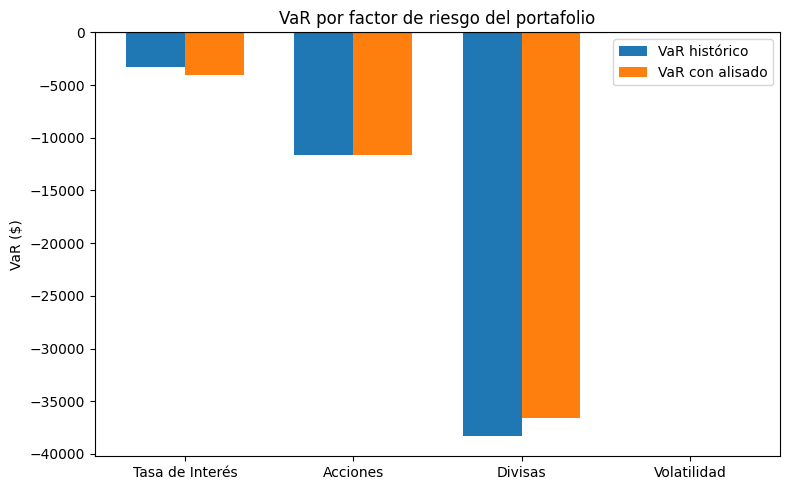

In [101]:
# @title 📋 Nivel factor de riesgo (portafolio) { display-mode: "both" }
def fila_factor(nombre, riesgo):
    return {
        "Factor de riesgo": nombre,
        "VaR Cuantil": np.round(riesgo["VaR_total_q"], 2),
        "CVaR Cuantil": np.round(riesgo["CVaR_total_q"], 2),
        "VaR": np.round(riesgo["VaR_total"], 2),
        "CVaR": np.round(riesgo["CVaR_total"], 2),
        "VaR alisado": np.round(riesgo["VaR_total_alisado"], 2),
        "CVaR alisado": np.round(riesgo["CVaR_total_alisado"], 2),
    }


resumen_factor = pd.DataFrame([
    fila_factor("Tasa de Inter\u00e9s", riesgo_bucket_ti),
    fila_factor("Acciones", riesgo_bucket_acciones),
    fila_factor("Divisas", riesgo_bucket_divisas),
    fila_factor("Volatilidad", riesgo_bucket_vol),
])

display(resumen_factor)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(resumen_factor))
ancho = 0.35
ax.bar(x - ancho / 2, resumen_factor["VaR"], ancho, label="VaR hist\u00f3rico")
ax.bar(x + ancho / 2, resumen_factor["VaR alisado"], ancho, label="VaR con alisado")
ax.set_xticks(x)
ax.set_xticklabels(resumen_factor["Factor de riesgo"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("VaR ($)")
ax.set_title("VaR por factor de riesgo del portafolio")
ax.legend()
plt.tight_layout()
plt.show()


In [102]:
# @title 📋 Nivel total (portafolio) { display-mode: "both" }
resumen_total = pd.DataFrame([{
    "Valor de mercado": np.round(V0T_port, 2),
    "VaR Cuantil": np.round(riesgo_portafolio_total["VaR_total_q"], 2),
    "CVaR Cuantil": np.round(riesgo_portafolio_total["CVaR_total_q"], 2),
    "VaR": np.round(riesgo_portafolio_total["VaR_total"], 2),
    "CVaR": np.round(riesgo_portafolio_total["CVaR_total"], 2),
    "VaR alisado": np.round(riesgo_portafolio_total["VaR_total_alisado"], 2),
    "CVaR alisado": np.round(riesgo_portafolio_total["CVaR_total_alisado"], 2),
}])

display(resumen_total)


,Valor de mercado,VaR Cuantil,CVaR Cuantil,VaR,CVaR,VaR alisado,CVaR alisado
0,976584.47,-47267.39,-68075.85,-47880.44,-64709.95,-53972.28,-56752.01


# ✅ Glosario y para seguir practicando

### Glosario rápido
- **VaR (Valor en Riesgo):** la pérdida que, con cierto nivel de confianza `alpha`, no se espera superar en un día.
- **CVaR / Expected Shortfall:** la pérdida promedio en los escenarios que sí superan el VaR (más sensible a colas extremas).
- **Simulación histórica:** VaR/CVaR calculado revaluando la cartera bajo escenarios de mercado realmente observados en el pasado.
- **VaR con alisado:** igual, pero ponderando cada escenario histórico según qué tan reciente es (factor `w0`), en vez de que todos pesen igual.
- **Factor de riesgo:** cada curva/precio de mercado del que depende la valuación (curva de descuento, tasa spot, volatilidad, tipo de cambio, precio de una acción, etc.).
- **Nivel contrato / instrumento / factor de riesgo / total:** las cuatro formas de agregar el riesgo — por posición individual, por tipo de instrumento, por tipo de factor de mercado (sin importar el instrumento), y para toda la cartera.

### 🧪 Ejercicios sugeridos
1. Cambia `factor_alisado` (w0): con un w0 más grande, el VaR con alisado reacciona más rápido a movimientos recientes. Compáralo contra el histórico simple.
2. Cambia `metodo_interpolacion` a "Tasa alambrada" y observa qué instrumentos cambian más su VaR.
3. Sube o baja `rendimiento_dividendos_ipc`: como es una tasa fija (no varía históricamente), no debería cambiar el VaR del Forward de Índices — verifica que así sea.
4. Agrega una posición nueva a cualquier instrumento (editando su celda de parámetros) y seguí el efecto en las 4 tablas del resumen integral.
5. Compara `resumen_factor` (por tipo de factor) contra la suma de `resumen_instrumento` (por instrumento): ¿por qué no dan exactamente lo mismo si sumas VaRs directamente, pero sí coinciden si sumas las pérdidas y ganancias (PG) antes de calcular el VaR? (pista: diversificación / no-linealidad del cuantil).
